# Setup

In [1]:
# Libs
import phobos
import numpy as np
import matplotlib.pyplot as plt
import time
import pickle
from tqdm import tqdm
import sys

✅ BMC lib found. Running in control mode.


In [2]:
# Constants
lam = 1550 # [nm]
light_lam = 1550 # [nm]

In [3]:
# shortcuts
dm = phobos.DM()
cam = phobos.Cred3()
chip = phobos.Arch6()
chip.turn_off()
inj_seg = phobos.Config().get('injection.segments')
print('Injected segments:', inj_seg)

# Setup
path = phobos.archive.new('env_drift_lam%s'%(light_lam), verbose=True)


DEBUG - SDK Install Path: /opt/Boston Micromachines
DEBUG - BMC_PCIeOpenDM 27BW007#051 0
DEBUG - 1 BMC PCIe cards installed.
DEBUG - Using automatic devId: 1
DEBUG - BMC_PCIeOpenDM opening 0
INFO - PCIe HW Rev: 20000502
DEBUG - Loading map file: /opt/Boston Micromachines/Map/KILO507.map expected count: 1024
INFO - Loading calibration for DM: 27BW07#051_5_3_setof14
DEBUG - Loading map file: /opt/Boston Micromachines/Map/KILO507.map expected count: 1024
Cred3 camera initialized with dark subtraction
Injected segments: [138, 137, 136, 135]
Archive created at /mnt/disk1/archive/2026-04-20_fdfc996/2_env_drift_lam1550


In [4]:
phobos.Config().set('dm.stabilization_time', 0.002, autosave=False)
phobos.Config().set('photonic_chip.stabilization_time', 0.01, autosave=False)

# Check cropping

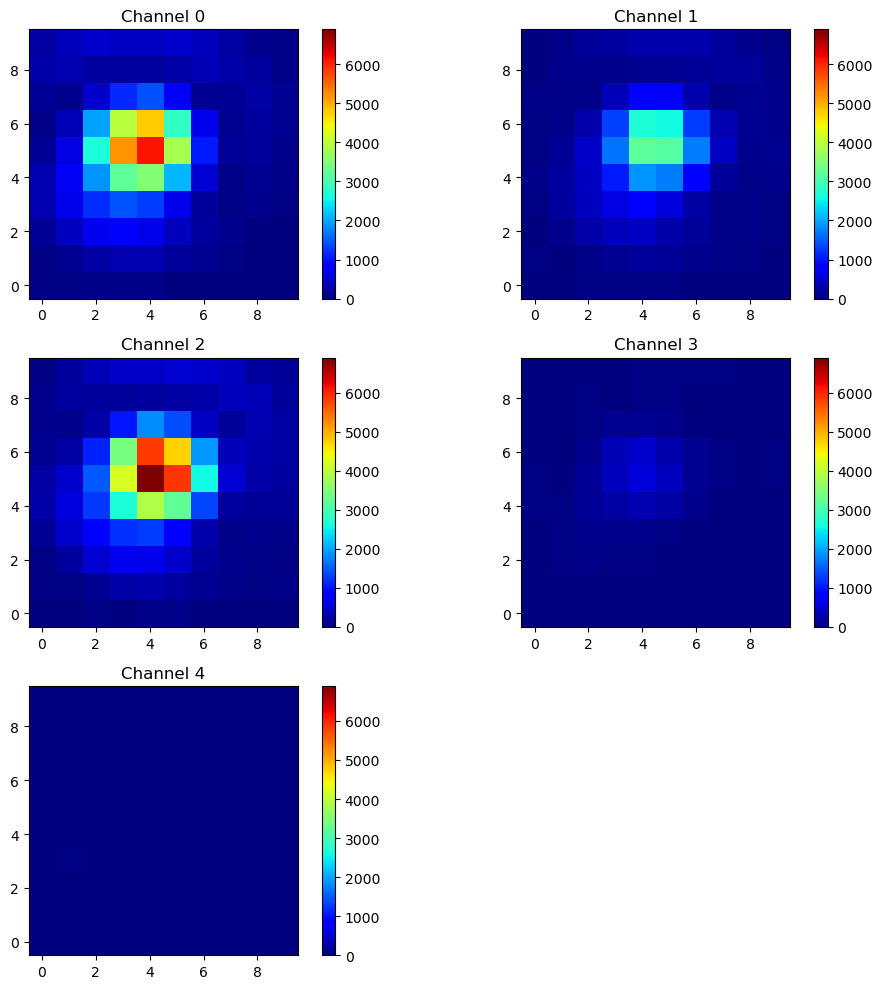

In [5]:
# check cropping
cam.check_cropping()

# Calibration injection

In [6]:
# Injection calibration
inj = phobos.Injection()


Scanning injection maps:   0%|          | 0/4 [00:00<?, ?it/s]

  Channel 0 (segment 138): scanning…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])


Scanning injection maps:  25%|██▌       | 1/4 [00:14<00:43, 14.62s/it]

Injection OFF on channels [0] (segments [138])
  Channel 1 (segment 137): scanning…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])


Scanning injection maps:  50%|█████     | 2/4 [00:27<00:27, 13.60s/it]

...

Injection OFF on channels [2] (segments [136])
  Channel 3 (segment 135): scanning…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])


Scanning injection maps: 100%|██████████| 4/4 [00:57<00:00, 14.45s/it]

Injection OFF on channels [3] (segments [135])
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])

── Find gross TT for max injection and spread ──
Injection spread of seg=138: (tip, tilt) = (0.82338,0.69861) mrad
Injection spread of seg=137: (tip, tilt) = (0.72114,0.79578) mrad
Injection spread of seg=136: (tip, tilt) = (0.70422,0.77692) mrad
Injection spread of seg=135: (tip, tilt) = (0.72242,0.79247) mrad

── Find precise TT for max injection ──
Injection max of seg=138: (tip, tilt) = (-2.61401,1.43930) mrad; flux = -906.6
Injection max of seg=137: (tip, tilt) = (-0.75474,0.62877) mrad; flux = 796.8
Injection max of seg=136: (tip, tilt) = (-0.34064,0.55305) mrad; flux = 786
Injection max of seg=135: (tip, tilt) = (-0.19311,0.54900) mrad; flux = 813.4
✅ Injection calibration saved to config (injection.max)



/home/photonics/Progs/repos/PHOBos/src/phobos/classes/injection.py:506: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(twoD_Gaussian, (x, y), data.ravel(), p0=initial_guess)



── Finding maximum injection points ──

── Balancing injection fluxes ──
  Weakest channel: 2 (seg 136), target flux = 752.1
  Dichotomy on channel 0 (seg 138)…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])
    → balanced tilt = 0.9555 mrad, flux = 755.3 (target 752.1), iterations = 13
  Dichotomy on channel 1 (seg 137)…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])
    → balanced tilt = 0.7487 mrad, flux = 752.9 (target 752.1), iterations = 13
  Dichotomy on channel 3 (seg 135)…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])
    → balanced tilt = 0.8559 mrad, flux = 750.5 (target 752.1), iterations = 13
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
✅ Injection calibration saved to config (injection.balanced)


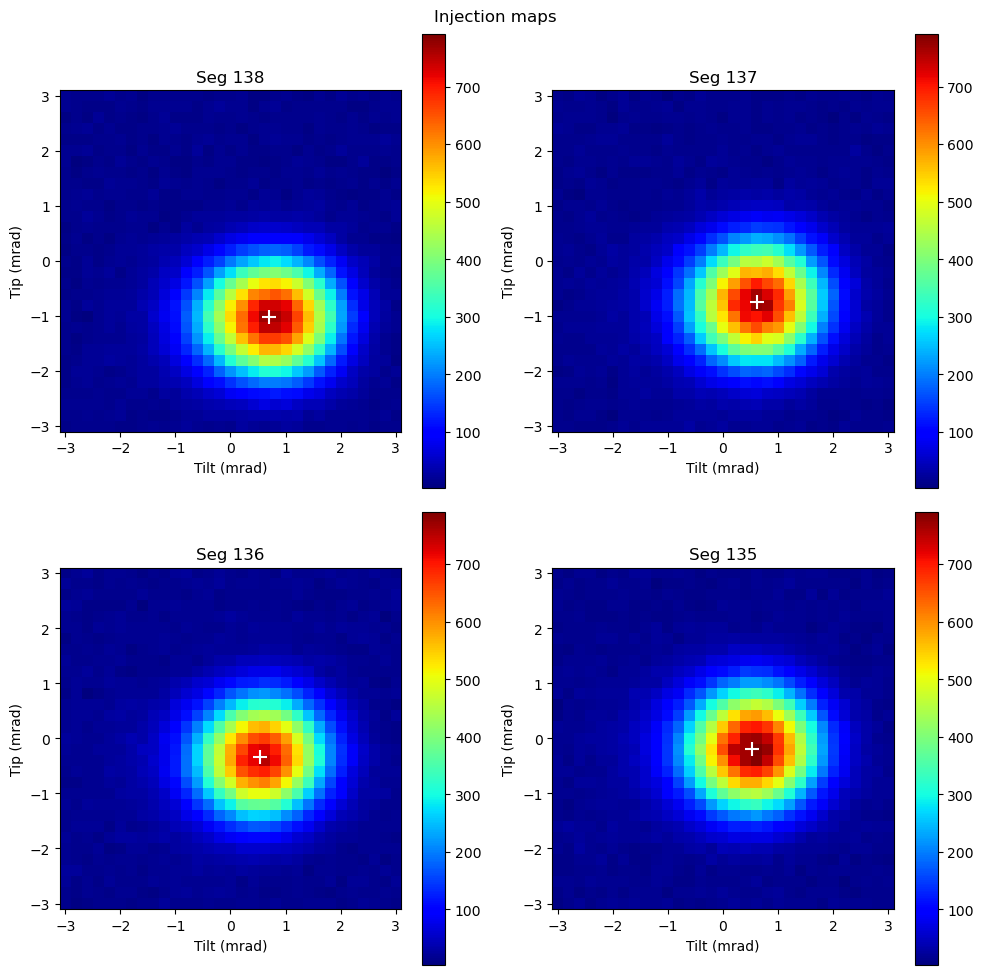

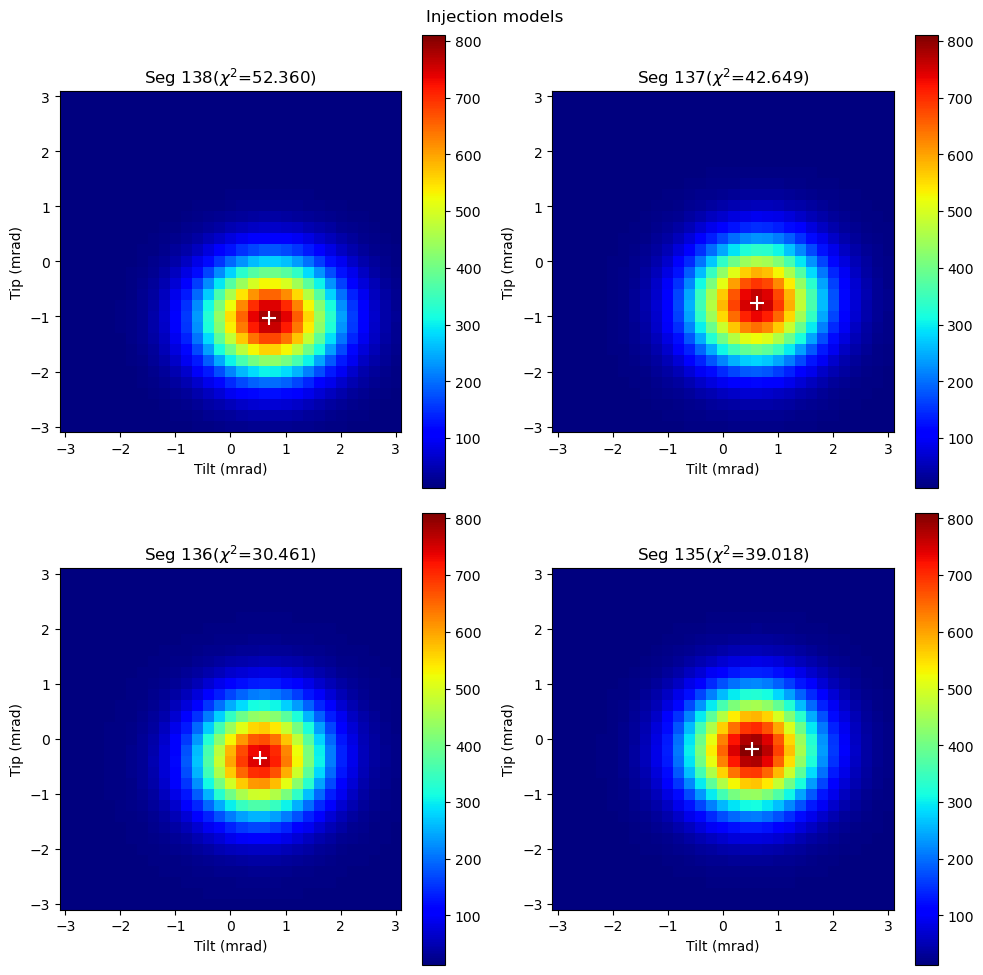

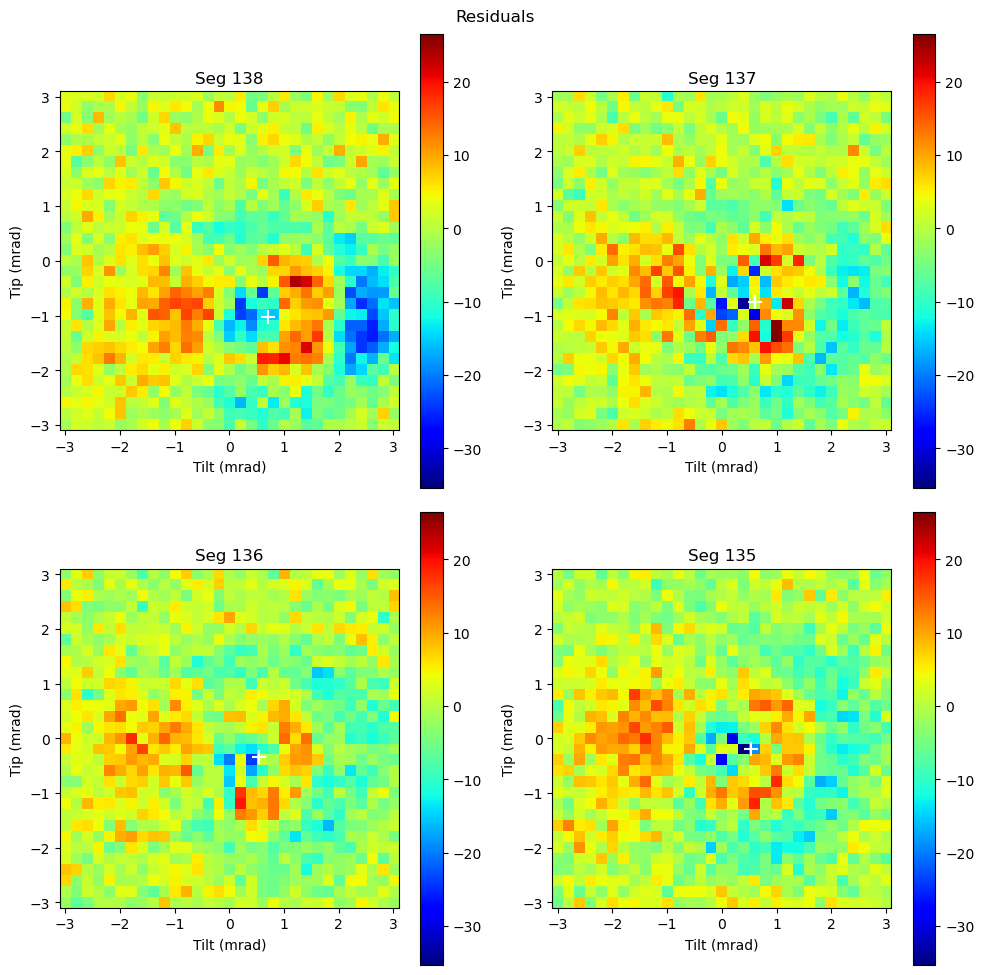

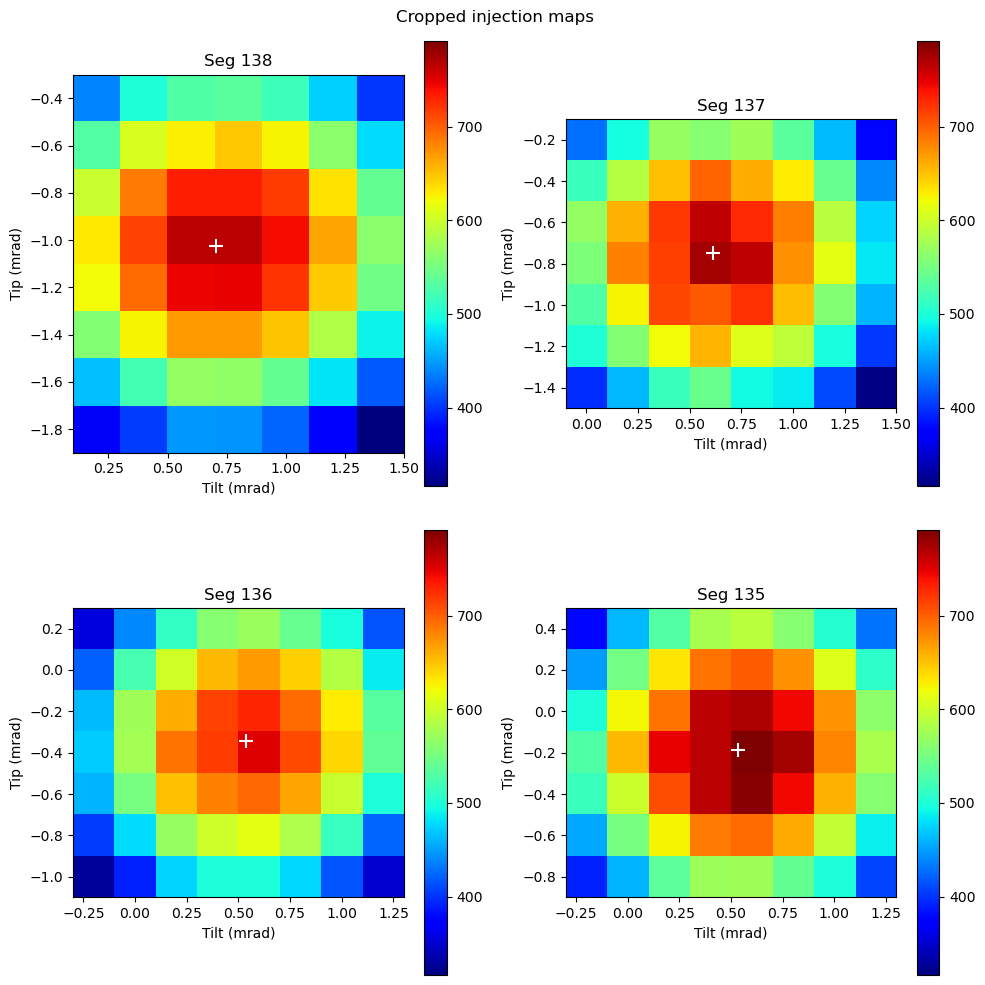

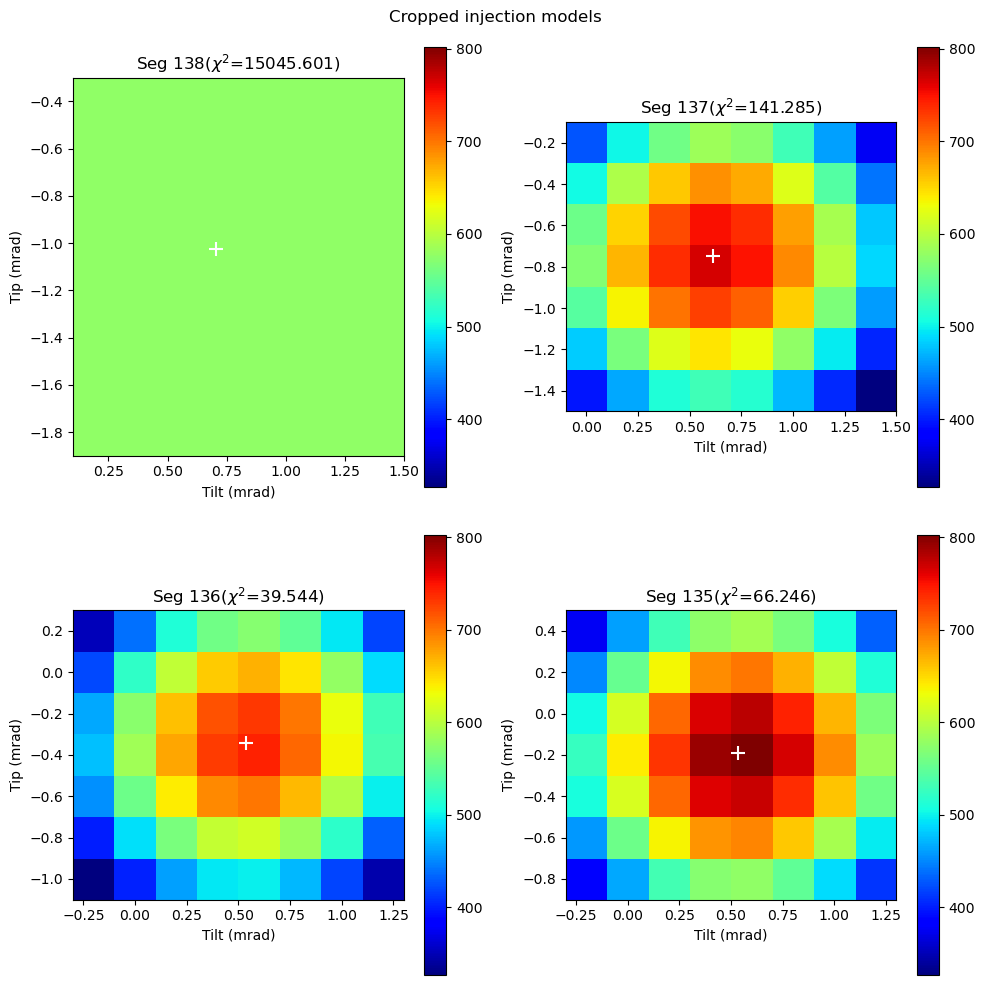

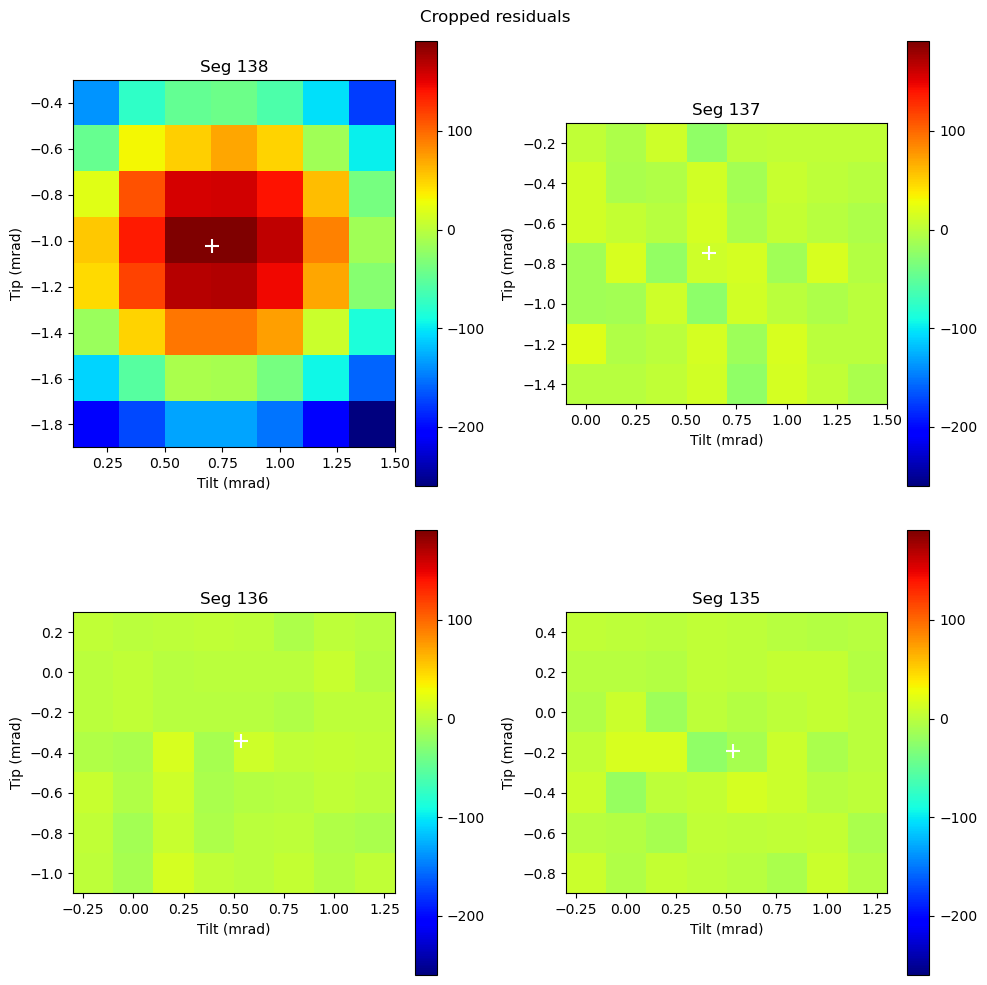

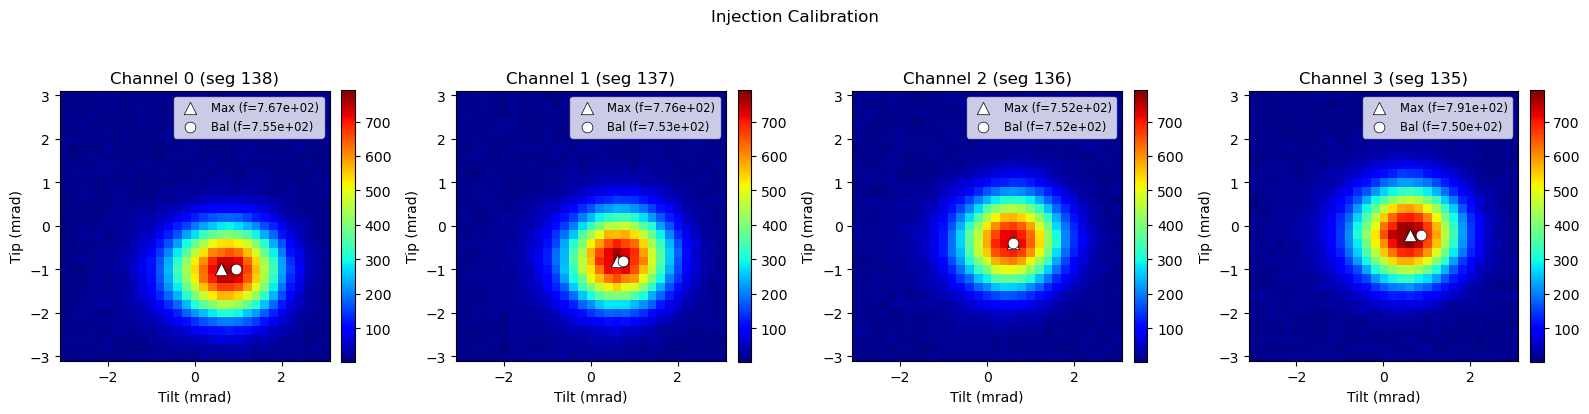

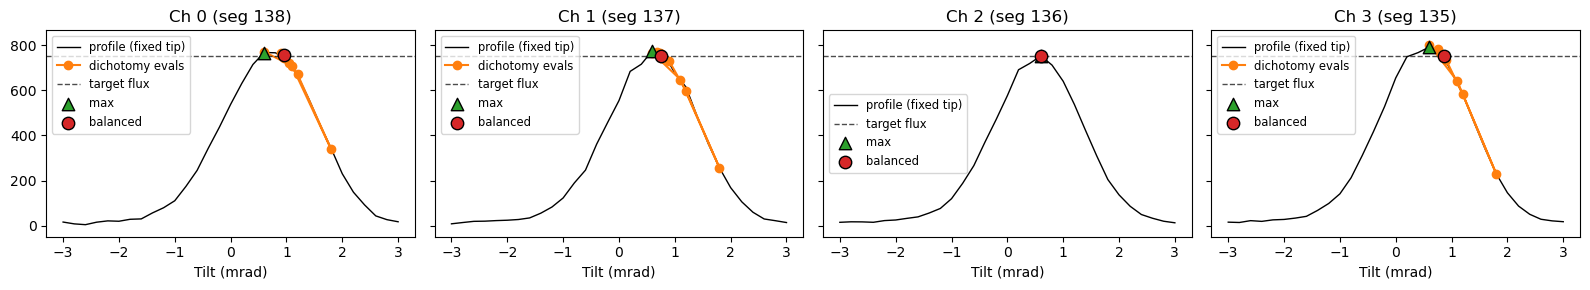

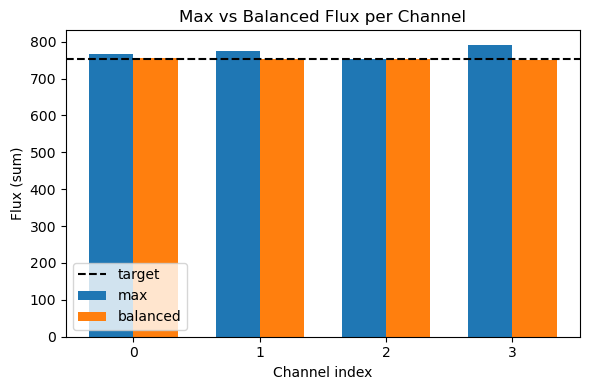

Successfully saved in FITS
Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


In [13]:
# Injection calibration
avg_frame = 1
avg_frames_bal = 5
out_inj = inj.calibrate(verbose=True, plot=True, save_path=path, 
                        avg_frames=avg_frame, avg_frames_bal=avg_frames_bal,
                        tilt_tol = 0.5e-3, check_focus=False)

inj.zero()

# Phase shifter calibration

Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
  - Scanning shifter 17...
  ✅ Shifter 17 calibrated: Period=0.5922 W -> Coeff=0.0943 W/rad
  - Scanning shifter 18...
  ✅ Shifter 18 calibrated: Period=0.5966 W -> Coeff=0.0950 W/rad
  - Scanning shifter 19...
  ✅ Shifter 19 calibrated: Period=0.5968 W -> Coeff=0.0950 W/rad
  - Scanning shifter 20...
  ✅ Shifter 20 calibrated: Period=0.5974 W -> Coeff=0.0951 W/rad


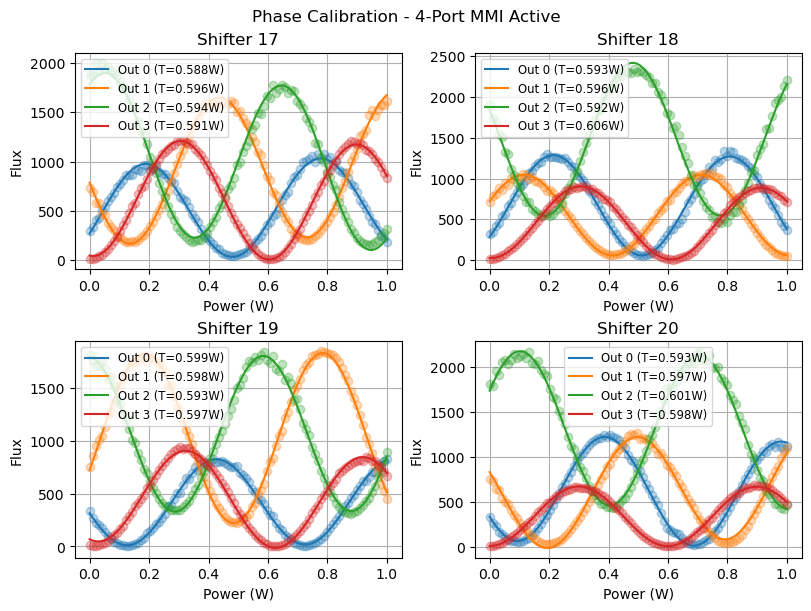

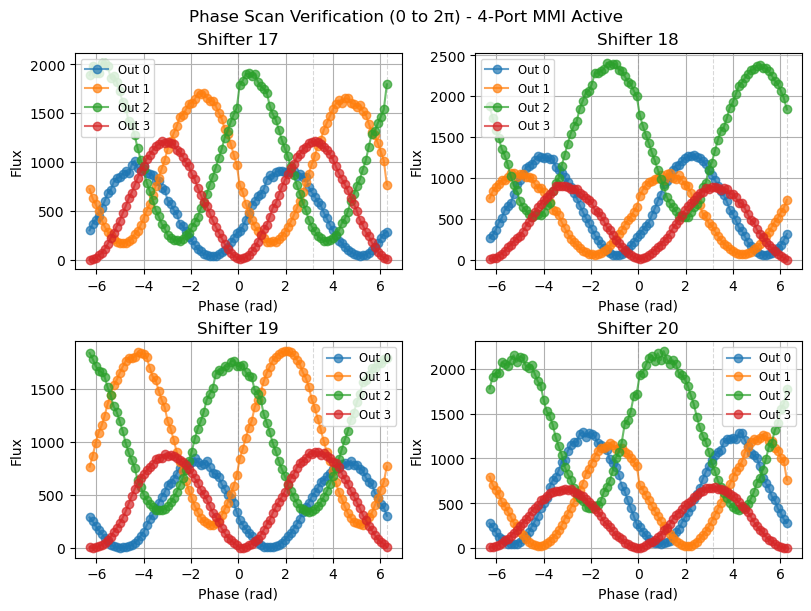

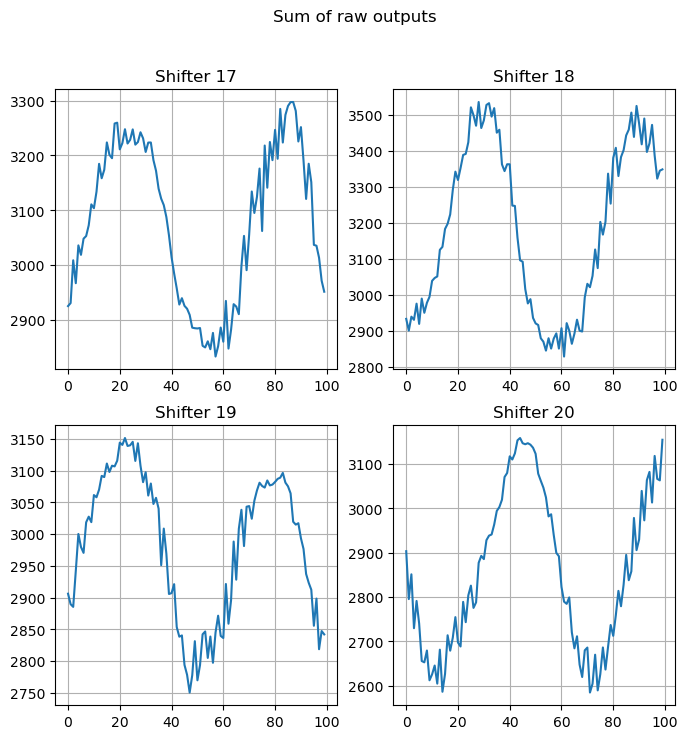

In [7]:
inj.set_balanced()

avg_frames = 5
# TOPAs calibration
# chip_coeffs, chip_scans, chip_power_range = chip.phase_calibration2(niter = 5, plot=True, verbose=True, avg_frames=avg_frames)
chip_coeffs, chip_scans, chip_power_range = chip.phase_calibration(plot=True, verbose=False)

np.save(path / "chip_coeffs.npy", chip_coeffs)
np.savez(path / "chip_scans.npz", chip_scans=chip_scans, chip_power_range=chip_power_range)

s = chip_scans[:,:,::-1].sum(2)
plt.figure(figsize=(8,8))
plt.suptitle("Sum of raw outputs")
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(s[i].T)
    plt.grid()
    plt.title(f"Shifter {chip.shifters[i].channel}")

chip.turn_off()
    

# Mono-beam scan
## Balanced positions

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0] (segments [138])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1] (segments [137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [2] (segments [136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [3] (segments [135])
Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


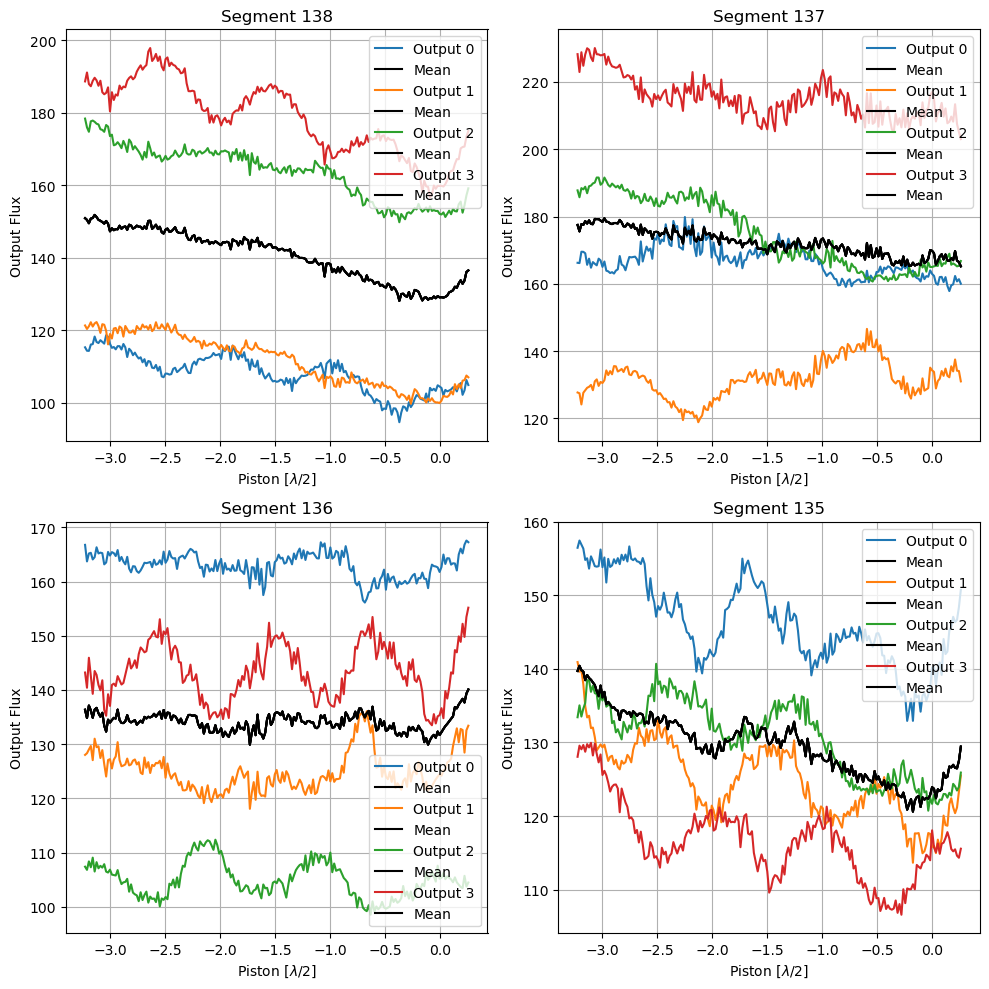

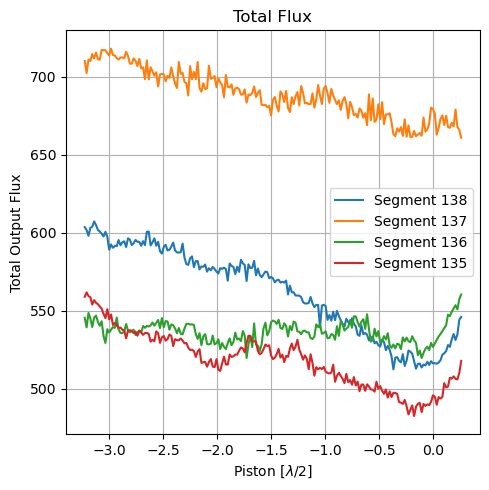

In [ ]:
n_roi = 4
avg_frames = 5
piston_range = np.linspace(-2500, 200, 201)  # [nm]
n_ch = len(inj_seg)
res_single_scan = {}
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

total_flux = []
for beam in range(n_ch):
    inj.off()
    inj.set_balanced(beam)

    ref_tip = dm[inj_seg[beam]].get_tip()
    ref_tilt = dm[inj_seg[beam]].get_tilt()

    outs = np.empty((len(piston_range), n_roi))
    for p, opd in enumerate(piston_range):
        dm[inj_seg[beam]].set_ptt(opd, ref_tip, ref_tilt)
        time.sleep(0.005)
        outs[p] = cam.get_outputs(flux_mode='mean', stack=avg_frames)[:n_roi]

    res_single_scan[inj_seg[beam]] = outs.copy()
    total_flux.append(outs[:].sum(axis=1))

    for o in range(n_roi):
        axs[beam].plot(piston_range / (lam/2), outs[:, o], color=colors[o], linestyle='-', label=f'Output {o}')
        axs[beam].plot(piston_range / (lam/2), outs.mean(1), color='k', linestyle='-', label=f'Mean')
    axs[beam].set_title(f'Segment {inj_seg[beam]}')
    axs[beam].set_xlabel(r'Piston [$\lambda/2$]')
    axs[beam].set_ylabel('Output Flux')
    axs[beam].legend()
    axs[beam].grid()


fig.tight_layout()
fig.savefig(path / 'singlebeam_scan_max.png')

total_flux = np.array(total_flux)
fig, axs = plt.subplots(1, 1, figsize=(5, 5))

for o in range(n_ch):
    axs.plot(piston_range / (lam/2), total_flux[o], 
             color=colors[o], linestyle='-', label=f'Segment {inj_seg[o]}')
axs.set_title('Total Flux')
axs.set_xlabel('Piston [$\lambda/2$]')
axs.set_ylabel('Total Output Flux')
axs.legend()
axs.grid()
fig.tight_layout()
fig.savefig(path / 'singlebeam_scan_balanced_totalflux.png')

inj.set_balanced()


## Max position

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection MAX on channels [0] (segments [138])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection MAX on channels [1] (segments [137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection MAX on channels [2] (segments [136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection MAX on channels [3] (segments [135])
Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


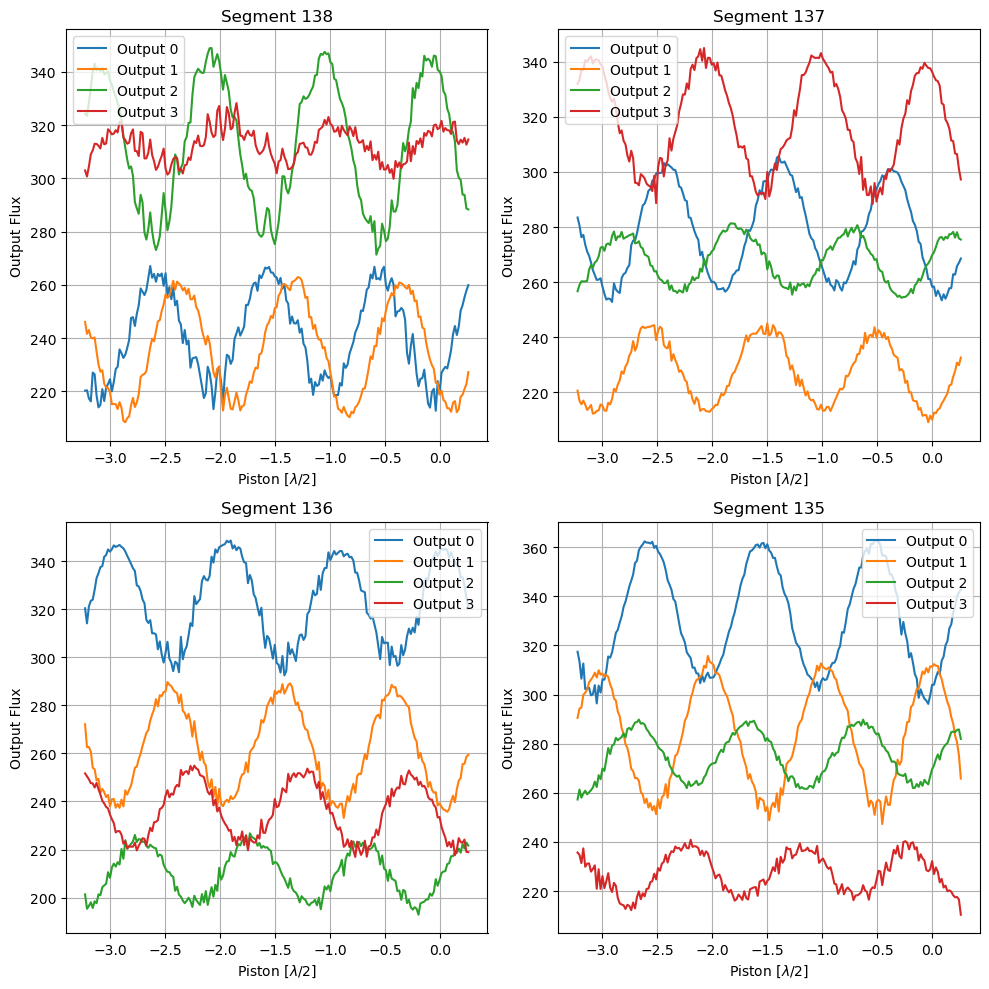

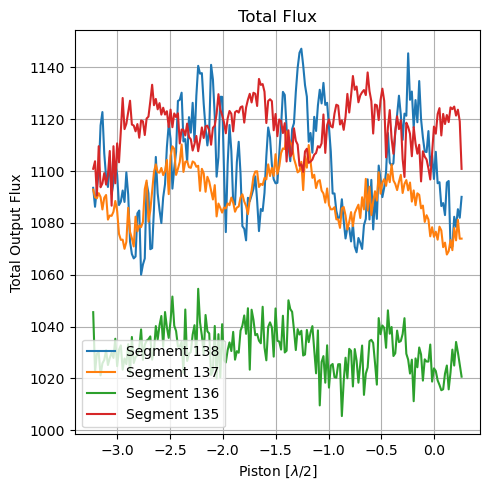

In [ ]:
n_roi = 4
piston_range = np.linspace(-2500, 200, 201)  # [nm]
n_ch = len(inj_seg)
res_single_scan = {}
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
avg_frames = 5

total_flux = []
for beam in range(n_ch):
    inj.off()
    inj.set_max(beam)

    ref_tip = dm[inj_seg[beam]].get_tip()
    ref_tilt = dm[inj_seg[beam]].get_tilt()

    outs = np.empty((len(piston_range), n_roi))
    for p, opd in enumerate(piston_range):
        dm[inj_seg[beam]].set_ptt(opd, ref_tip, ref_tilt)
        time.sleep(0.005)
        outs[p] = cam.get_outputs(flux_mode='mean', stack=avg_frames)[:n_roi]

    res_single_scan[inj_seg[beam]] = outs.copy()
    total_flux.append(outs[:].sum(axis=1))

    for o in range(n_ch):
        axs[beam].plot(piston_range / (lam / 2), outs[:, o], color=colors[o], linestyle='-', label=f'Output {o}')

    axs[beam].set_title(f'Segment {inj_seg[beam]}')
    axs[beam].set_xlabel(r'Piston [$\lambda/2$]')
    axs[beam].set_ylabel('Output Flux')
    axs[beam].legend()
    axs[beam].grid()


fig.tight_layout()
fig.savefig(path / 'singlebeam_scan_max.png')

total_flux = np.array(total_flux)
fig, axs = plt.subplots(1, 1, figsize=(5, 5))

for o in range(n_ch):
    axs.plot(piston_range / (lam / 2), total_flux[o], color=colors[o], linestyle='-', label=f'Segment {inj_seg[o]}')

axs.set_title('Total Flux')
axs.set_xlabel(r'Piston [$\lambda/2$]')
axs.set_ylabel('Total Output Flux')
axs.legend()
axs.grid()
fig.tight_layout()
fig.savefig(path / 'singlebeam_scan_max_totalflux.png')

inj.set_balanced()

# Physically blocked beam

Segment: 138
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0] (segments [138])


KeyboardInterrupt: 

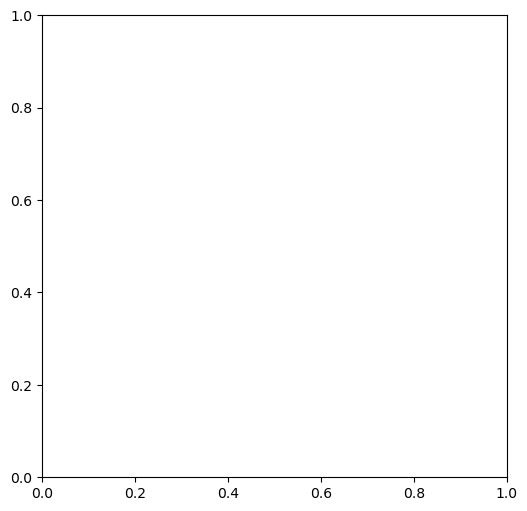

In [ ]:
n_roi = 4
avg_frames = 5
piston_range = np.linspace(-2500, 200, 201)  # [nm]
beam = 0
seg = inj_seg[beam]
print('Segment:', seg)

res_single_scan = {}
fig, axs = plt.subplots(1, 1, figsize=(6, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

total_flux = []
inj.off()
inj.set_balanced(beam)

ref_tip = dm[inj_seg[beam]].get_tip()
ref_tilt = dm[inj_seg[beam]].get_tilt()

outs = np.empty((len(piston_range), n_roi))
for p, opd in enumerate(piston_range):
    dm[inj_seg[beam]].set_ptt(opd, ref_tip, ref_tilt)
    time.sleep(0.005)
    outs[p] = cam.get_outputs(flux_mode='mean', stack=avg_frames)[:n_roi]

res_single_scan[inj_seg[beam]] = outs.copy()
total_flux.append(outs[:].sum(axis=1))

for o in range(n_roi):
    axs.plot(piston_range / (lam/2), outs[:, o], color=colors[o], linestyle='-', label=f'Output {o}')
    axs.plot(piston_range / (lam/2), outs.mean(1), color='k', linestyle='-', label=f'Mean')
axs.set_title(f'Segment {inj_seg[beam]}')
axs.set_xlabel(r'Piston [$\lambda/2$]')
axs.set_ylabel('Output Flux')
axs.legend()
axs.grid()


fig.tight_layout()
fig.savefig(path / f'singlebeam_seg{seg}_scan_max.png')

total_flux = np.array(total_flux)
fig, axs = plt.subplots(1, 1, figsize=(5, 5))

for o in range(1):
    axs.plot(piston_range / (lam/2), total_flux[o], 
             color=colors[o], linestyle='-', label=f'Segment {inj_seg[o]}')
axs.set_title('Total Flux')
axs.set_xlabel('Piston [$\lambda/2$]')
axs.set_ylabel('Total Output Flux')
axs.legend()
axs.grid()
fig.tight_layout()
fig.savefig(path / f'singlebeam_seg{seg}_scan_balanced_totalflux.png')

inj.set_balanced()


# Pair scan

## With DM

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 1] (segments [138, 137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 1] (segments [138, 137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 2] (segments [138, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 2] (segments [138, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 3] (segments [138, 135])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 3] (segments [138, 135])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1, 2] (segments [137, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BA

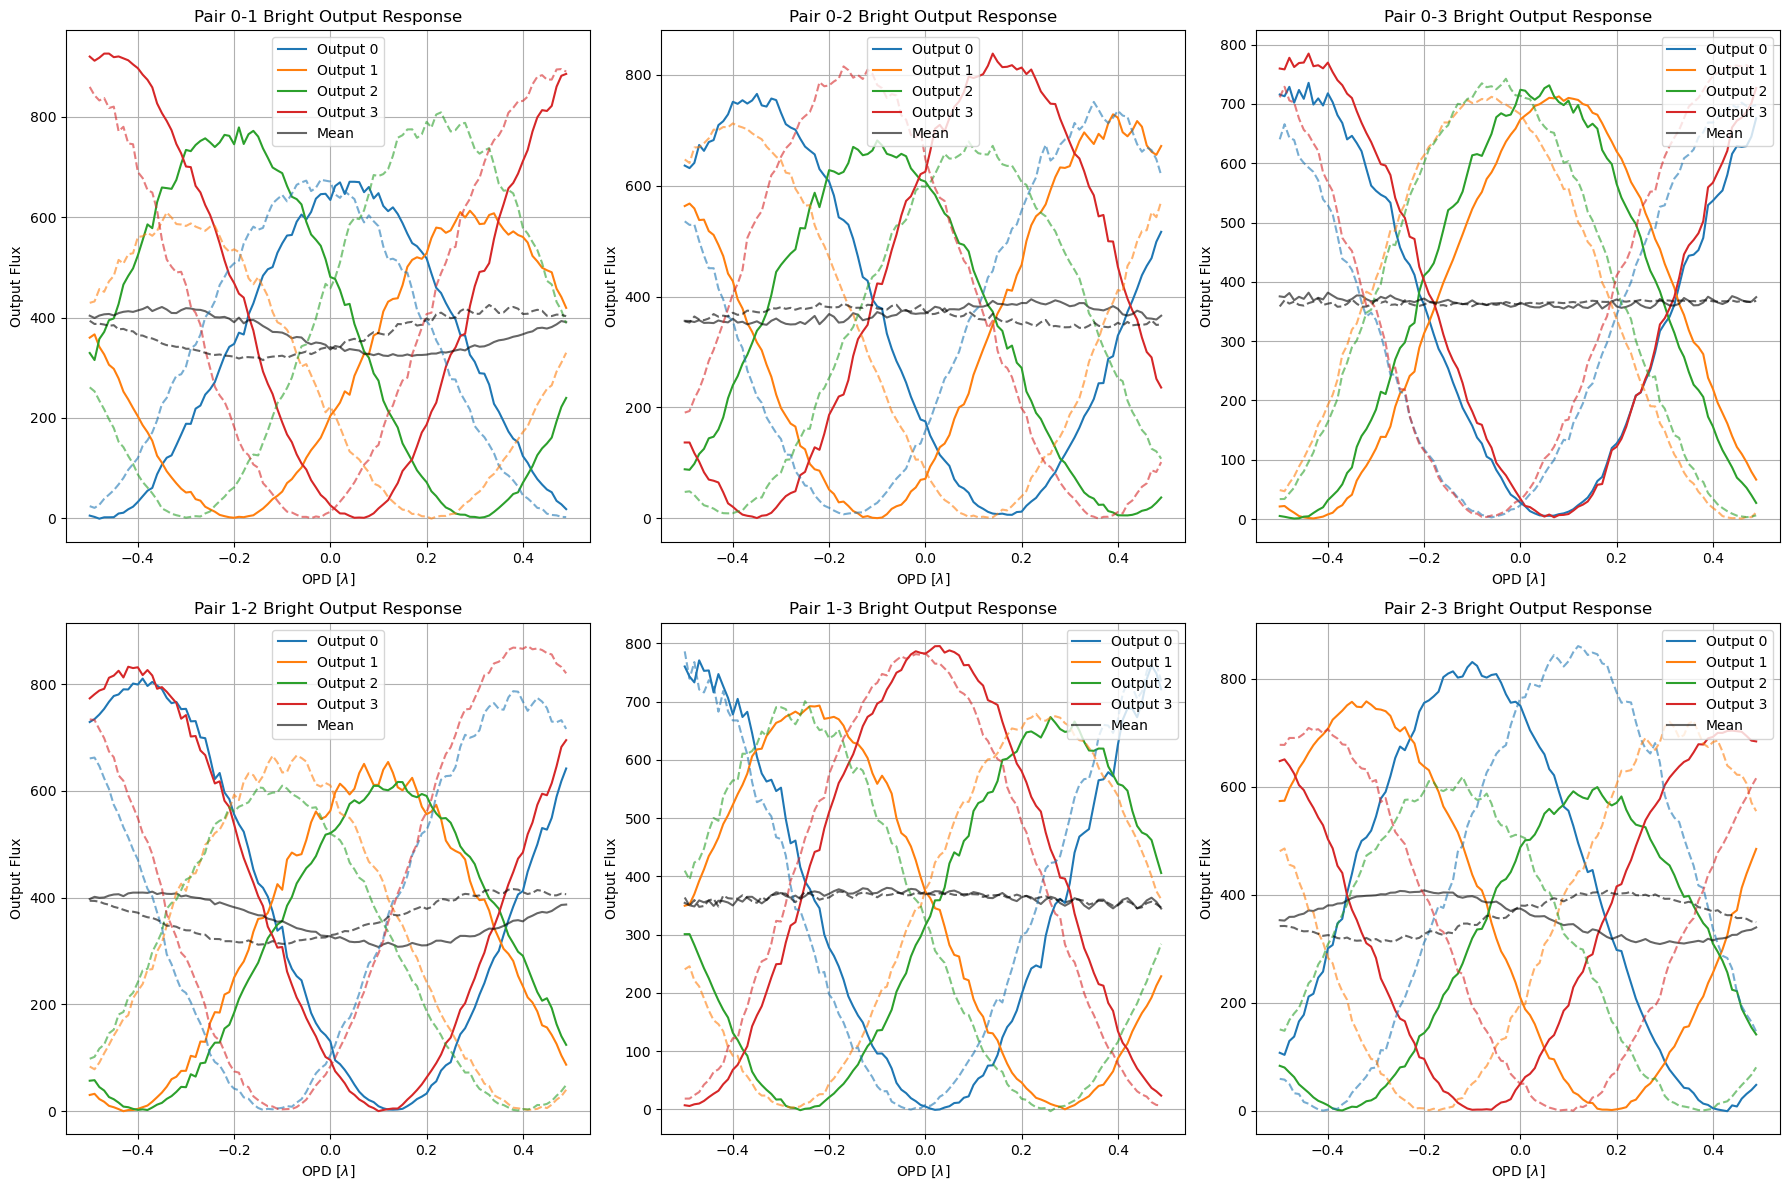

In [8]:
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
nb_lam = 1.
n_roi = cam.get_outputs(flux_mode='mean').size - 1

res_pair_scan = {}

fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for i, pair in enumerate(pairs):
    inj.off()
    inj.set_balanced(np.array(pair))

    ref_cart = dm[inj_seg[pair[1]]].get_piston()
    start = ref_cart - nb_lam * lam/2./2.
    piston_range = np.linspace(start, start + nb_lam * lam/2., 100, endpoint=False)  # [nm]
    opd_range = (piston_range - ref_cart) * 2

    ref_tip = (dm[inj_seg[pair[0]]].get_tip(), dm[inj_seg[pair[1]]].get_tip())
    ref_tilt = (dm[inj_seg[pair[0]]].get_tilt(), dm[inj_seg[pair[1]]].get_tilt())

    # Scan on first input
    outs = np.empty((len(piston_range), n_roi))
    for p, piston in enumerate(piston_range):
        dm[inj_seg[pair[0]]].set_ptt(piston, ref_tip[0], ref_tilt[0])
        if p == 0:
            time.sleep(0.1)
        outs[p] = cam.get_outputs(flux_mode='mean')[:n_roi]

    dm[inj_seg[pair[0]]].set_ptt(ref_cart, ref_tip[0], ref_tilt[0])
    time.sleep(0.1)

    data = np.hstack((opd_range[:,None], outs.copy()))
    res_pair_scan[(pair[0], pair[1])] = data

    for o in range(n_roi):
        axs[i].plot(opd_range / lam, outs[:, o], color=colors[o], label=f'Output {o}')
    axs[i].plot(opd_range / lam, outs.mean(1), color='k', linestyle='-', alpha=0.6, label='Mean')

    # Scan on second input
    inj.off()
    inj.set_balanced(np.array(pair))

    outs = np.empty((len(piston_range), n_roi))
    for p, piston in enumerate(piston_range):
        dm[inj_seg[pair[1]]].set_ptt(piston, ref_tip[1], ref_tilt[1])
        if p == 0:
            time.sleep(0.1)        
        outs[p] = cam.get_outputs(flux_mode='mean')[:n_roi]

    dm[inj_seg[pair[0]]].set_ptt(ref_cart, ref_tip[0], ref_tilt[0])
    time.sleep(0.1)

    data = np.hstack((opd_range[:,None], outs.copy()))
    res_pair_scan[(pair[1], pair[0])] = data

    for o in range(n_roi):
        axs[i].plot(opd_range / lam, outs[:, o], color=colors[o], linestyle='--', alpha=0.6)
    axs[i].plot(opd_range / lam, outs.mean(1), color='k', linestyle='--', alpha=0.6)
    
    axs[i].set_title(f'Pair {pair[0]}-{pair[1]} Bright Output Response')
    axs[i].set_xlabel(r'OPD [$\lambda$]')
    axs[i].set_ylabel('Output Flux')
    axs[i].legend()
    axs[i].grid()

fig.tight_layout()
filename = 'pair_dm_scan_start%.0f_nb_lam%s.png'%(start, nb_lam)
fig.savefig(path / filename, dpi=150, format='png')

filename = 'pair_dm_scan_data_start%.0f_nb_lam%s.pkl'%(start, nb_lam)
with open(path / filename, 'wb') as f:
    pickle.dump(res_pair_scan, f)


inj.set_balanced()

## With phase shifters

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 1] (segments [138, 137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 1] (segments [138, 137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 2] (segments [138, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 2] (segments [138, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 3] (segments [138, 135])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 3] (segments [138, 135])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1, 2] (segments [137, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BA

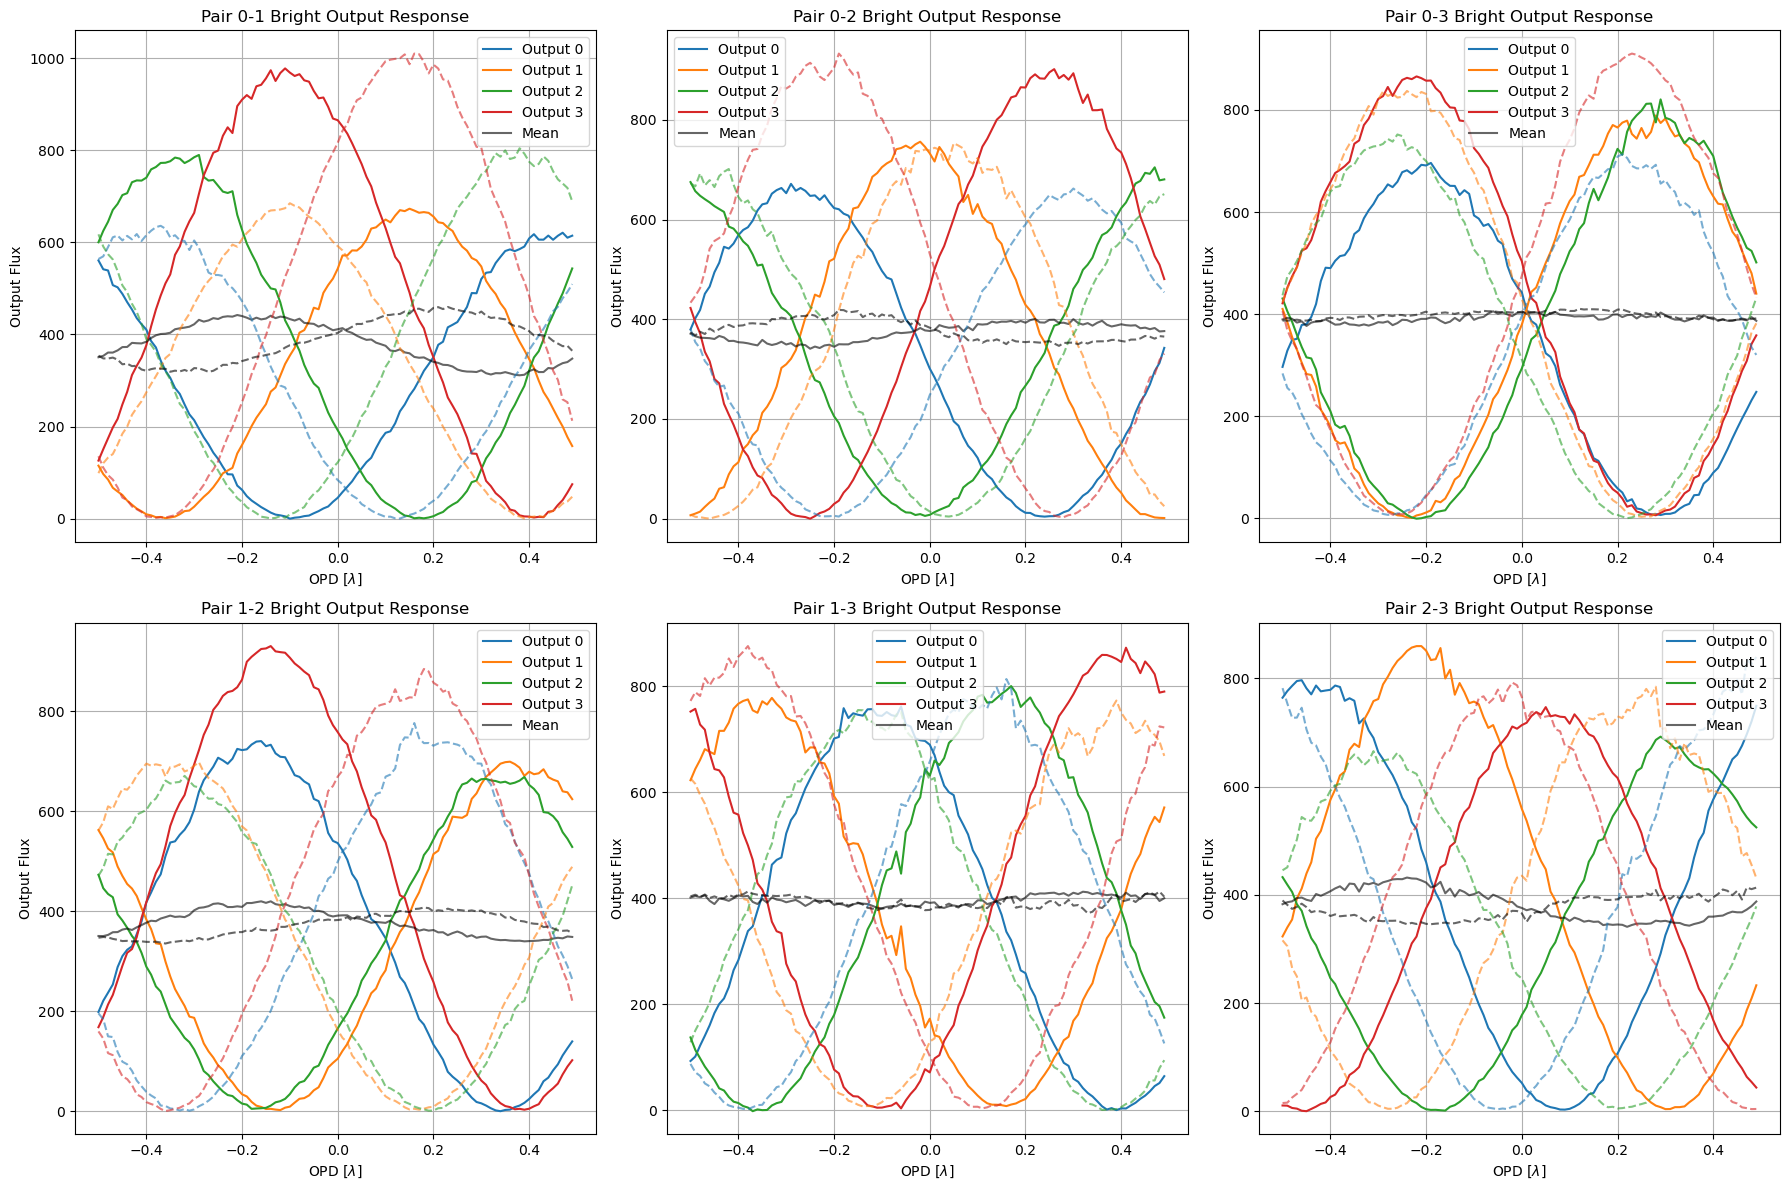

In [ ]:
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
nb_lam = 1.
n_roi = cam.get_outputs(flux_mode='mean').size - 1
phase_offset = np.pi

res_pair_scan_ps = {}

fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for i, pair in enumerate(pairs):
    inj.off()
    inj.set_balanced(np.array(pair))

    ref_cart = dm[inj_seg[pair[1]]].get_piston()
    start = ref_cart - nb_lam * lam/2./2.
    piston_range = np.linspace(start, start + nb_lam * lam/2., 100, endpoint=False)  # [nm]
    opd_range = (piston_range - ref_cart) * 2

    # Scan on first input
    outs = np.empty((len(piston_range), n_roi))
    for p, piston in enumerate(piston_range):
        phase = 2 * np.pi / lam * opd_range[p]
        phases = np.zeros(4)
        phases[pair[0]] = phase + phase_offset
        chip.set_phases(phases)
        outs[p] = cam.get_outputs(flux_mode='mean')[:n_roi]

    chip.turn_off()
    data = np.hstack((opd_range[:,None], outs.copy()))
    res_pair_scan_ps[(pair[0], pair[1])] = data

    for o in range(n_roi):
        axs[i].plot(opd_range / lam, outs[:, o], color=colors[o], label=f'Output {o}')
    axs[i].plot(opd_range / lam, outs.mean(1), color='k', linestyle='-', alpha=0.6, label='Mean')

    # Scan on second input
    inj.off()
    inj.set_balanced(np.array(pair))

    outs = np.empty((len(piston_range), 4))
    for p, piston in enumerate(piston_range):
        phase = 2 * np.pi / lam * opd_range[p]
        phases = np.zeros(4)
        phases[pair[1]] = phase + phase_offset
        chip.set_phases(phases)      
        outs[p] = cam.get_outputs(flux_mode='mean')[:n_roi]

    chip.turn_off()
    data = np.hstack((opd_range[:,None], outs.copy()))
    res_pair_scan_ps[(pair[1], pair[0])] = data

    for o in range(n_roi):
        axs[i].plot(opd_range / lam, outs[:, o], color=colors[o], linestyle='--', alpha=0.6)
    axs[i].plot(opd_range / lam, outs.mean(1), color='k', linestyle='--', alpha=0.6)
    
    axs[i].set_title(f'Pair {pair[0]}-{pair[1]} Bright Output Response')
    axs[i].set_xlabel(r'OPD [$\lambda$]')
    axs[i].set_ylabel('Output Flux')
    axs[i].legend()
    axs[i].grid()

fig.tight_layout()
filename = 'pair_ps_scan_start%.0f_nb_lam%s.png'%(start, nb_lam)
fig.savefig(path / filename)

filename = 'pair_ps_scan_data_start%.0f_nb_lam%s.pkl'%(start, nb_lam)
with open(path / filename, 'wb') as f:
    pickle.dump(res_pair_scan_ps, f)


inj.set_balanced()
chip.turn_off()

# Piston ramp with counter phase shift

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 1] (segments [138, 137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 1] (segments [138, 137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 2] (segments [138, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 2] (segments [138, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 3] (segments [138, 135])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 3] (segments [138, 135])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1, 2] (segments [137, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BA

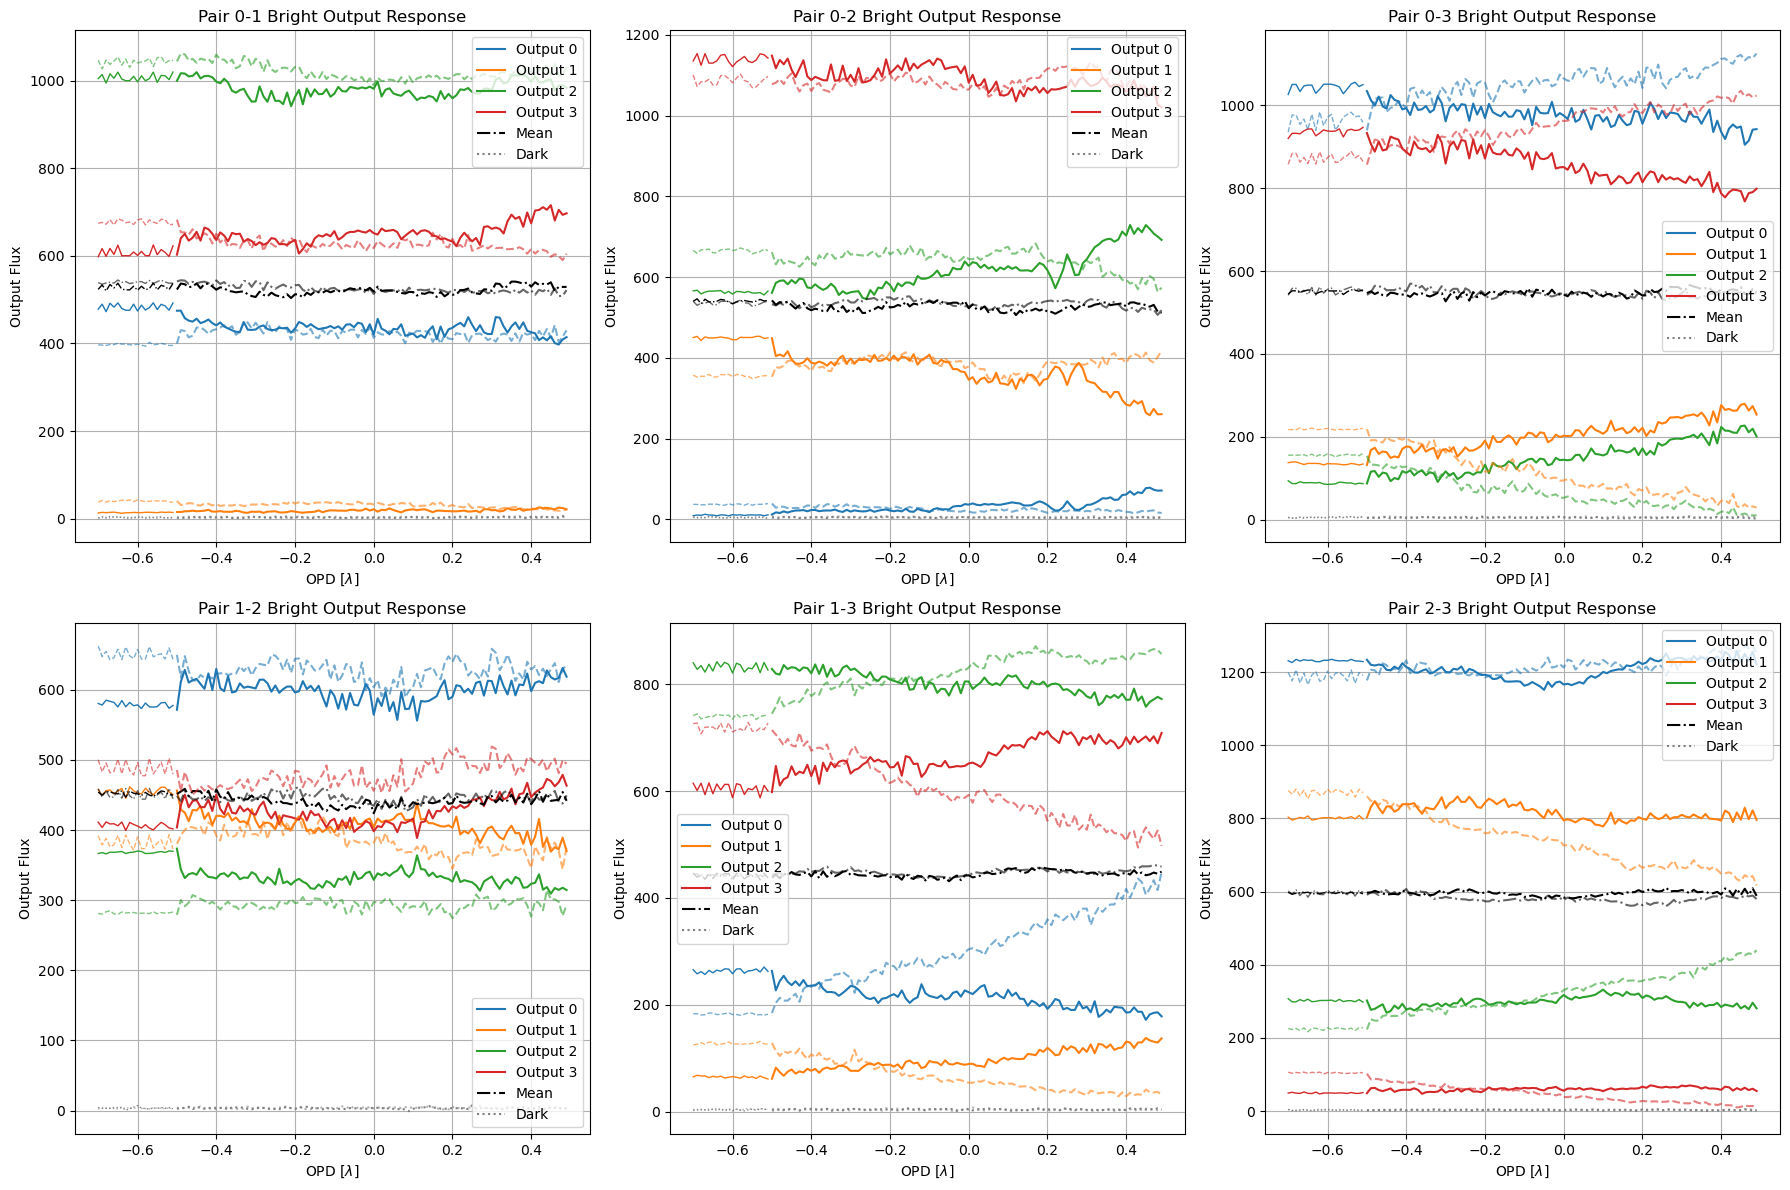

In [ ]:
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
start = -2500 # nm
nb_lam = 1.
n_roi = cam.get_outputs(flux_mode='mean').size
phase_offset = np.pi * 1.

# piston_range = np.linspace(start, start + nb_lam * lam/2., 201)  # [nm]


res_ramp_scan = {}

fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'black', 'grey']
for i, pair in enumerate(pairs):
    # Scan on first input
    inj.off()
    inj.set_balanced(np.array(pair))

    ref_tip = (dm[inj_seg[pair[0]]].get_tip(), dm[inj_seg[pair[1]]].get_tip())
    ref_tilt = (dm[inj_seg[pair[0]]].get_tilt(), dm[inj_seg[pair[1]]].get_tilt())

    ref_cart = dm[inj_seg[pair[1]]].get_piston()
    start = ref_cart - lam/2./2.
    piston_range = np.linspace(start, start + nb_lam * lam/2., 100, endpoint=False)  # [nm]
    opd_range = (piston_range - ref_cart) * 2

    pre_outs = np.empty((20, n_roi))
    outs = np.empty((len(piston_range), n_roi))
    for p, piston in enumerate(piston_range):
        phase = 2 * np.pi / lam * opd_range[p]
        phases = np.zeros(4)
        phases[pair[0]] = phase + phase_offset
        chip.set_phases(phases)
        dm[inj_seg[pair[0]]].set_ptt(piston, ref_tip[0], ref_tilt[0])
        if p == 0:
            time.sleep(0.1)
            for it in range(pre_outs.shape[0]):
                pre_outs[it] = cam.get_outputs(flux_mode='mean')[:n_roi]
        outs[p] = cam.get_outputs(flux_mode='mean')[:n_roi]

    pad_length = len(piston_range) - pre_outs.shape[0]
    pre_outs_padded = np.pad(pre_outs, ((0, pad_length), (0, 0)), mode='constant', constant_values=0)

    data = np.hstack((opd_range[:,None], outs.copy(), pre_outs_padded))
    res_ramp_scan[(pair[0], pair[1])] = data

    step = np.diff(opd_range)[0]
    pre_out_mock_axis = opd_range[0] + np.arange(-pre_outs.shape[0], 0) * step
 
    for o in range(n_roi-1):
        axs[i].plot(opd_range / lam, outs[:, o], color=colors[o], label=f'Output {o}')
        axs[i].plot(pre_out_mock_axis / lam, pre_outs[:, o], color=colors[o], linewidth=1)
    axs[i].plot(opd_range / lam, outs[:,:-1].mean(axis=1), color=colors[n_roi-1], linestyle='-.', label='Mean')
    axs[i].plot(opd_range / lam, outs[:,-1], color=colors[-1], linestyle=':', label='Dark')
    axs[i].plot(pre_out_mock_axis / lam, pre_outs[:,:-1].mean(axis=1), color=colors[n_roi-1], linestyle='-.', linewidth=1)
    axs[i].plot(pre_out_mock_axis / lam, pre_outs[:,-1], color=colors[-1], linestyle=':', linewidth=1)

    # Scan on second input
    inj.off()
    chip.set_phases([0,0,0,0])
    inj.set_balanced(np.array(pair))
    time.sleep(0.1)

    ref_cart = dm[inj_seg[pair[0]]].get_piston()
    opd_range = (piston_range - ref_cart) * 2    

    pre_outs = np.empty_like(pre_outs)
    outs = np.empty((len(piston_range), n_roi))
    for p, piston in enumerate(piston_range):
        phase = 2 * np.pi / lam * opd_range[p]
        phases = np.zeros(4)
        phases[pair[1]] = phase + phase_offset
        chip.set_phases(phases)        
        dm[inj_seg[pair[1]]].set_ptt(piston, ref_tip[1], ref_tilt[1])
        if p == 0:
            time.sleep(0.1)
            for it in range(pre_outs.shape[0]):
                pre_outs[it] = cam.get_outputs(flux_mode='mean')[:n_roi]            
        outs[p] = cam.get_outputs(flux_mode='mean')[:n_roi]

    phases[pair[1]] = 0.
    chip.set_phases(phases)

    pad_length = len(piston_range) - pre_outs.shape[0]
    pre_outs_padded = np.pad(pre_outs, ((0, pad_length), (0, 0)), mode='constant', constant_values=0)

    data = np.hstack((opd_range[:,None], outs.copy(), pre_outs_padded))
    res_ramp_scan[(pair[1], pair[0])] = data

    for o in range(n_roi-1):
        axs[i].plot(opd_range / lam, outs[:, o], color=colors[o], linestyle='--', alpha=0.6)
        axs[i].plot(pre_out_mock_axis / lam, pre_outs[:, o], color=colors[o], linestyle='--', linewidth=1, alpha=0.6)
    axs[i].plot(opd_range / lam, outs[:,:-1].mean(axis=1), color=colors[n_roi-1], linestyle='-.', alpha=0.6)
    axs[i].plot(opd_range / lam, outs[:,-1], color=colors[-1], linestyle=':', alpha=0.6)
    axs[i].plot(pre_out_mock_axis / lam, pre_outs[:,:-1].mean(axis=1), color=colors[n_roi-1], linestyle='-.', linewidth=1, alpha=0.6)
    axs[i].plot(pre_out_mock_axis / lam, pre_outs[:,-1], color=colors[-1], linestyle=':', linewidth=1, alpha=0.6)

    axs[i].set_title(f'Pair {pair[0]}-{pair[1]} Bright Output Response')
    axs[i].set_xlabel(r'OPD [$\lambda$]')
    axs[i].set_ylabel('Output Flux')
    axs[i].legend()
    axs[i].grid()
    

fig.tight_layout()
filename = 'ramp_nb_start%.1f_lam%.1f_offset_pi.png'%(start, nb_lam)
fig.savefig(path / filename)

filename = 'ramp_data_nb_start%.1f_lam%.1f_offset_pi.pkl'%(start, nb_lam)
with open(path / filename, 'wb') as f:
    pickle.dump(res_ramp_scan, f)

inj.set_balanced()
chip.turn_off()

# Upstream piston RMS regimes

In [ ]:
def rms_scan(n, rms_values, wl, pair, correct_with_topas=False, plot=True, use_dm=True):
    inj.off()
    chip.set_phases([0, 0, 0, 0])
    inj.set_balanced(pair)
    ref_cart = dm[inj_seg[pair[1]]].get_piston()
    print('Ref positions:', ref_cart)
    ref_tip = (dm[inj_seg[pair[0]]].get_tip(), dm[inj_seg[pair[1]]].get_tip())
    ref_tilt = (dm[inj_seg[pair[0]]].get_tilt(), dm[inj_seg[pair[1]]].get_tilt())
    n_outputs = cam.get_outputs(flux_mode='mean').size

    res = {}

    if plot:
        fig, axs = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle(f'Upstream Piston RMS Regimes - Pair {pair[0]}-{pair[1]}', fontsize=16)
        axs = axs.flatten()
        colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'black', 'grey']
    else:
        fig = None

    for i, rms in enumerate(rms_values):
        try:
            rms_text = 'lambda/%.4f...'%(lam/rms)
        except ZeroDivisionError:
            rms_text = '0 lambda'
        print('Scanning RMS=%.4f nm' % (rms) + ' --- ' + rms_text)

        outs = np.empty((n, n_outputs))
        res_pistons = np.empty((n, 2))
        res_phases = np.empty((n,))
        np.random.seed(0)
        for p in tqdm(range(n)):
            pistons = np.random.normal(ref_cart, rms/2)  # [nm]

            if use_dm:
                dm[inj_seg[pair[0]]].set_ptt(pistons, ref_tip[0], ref_tilt[0])
                # dm[inj_seg[pair[0]]].set_piston(pistons)

            opd = (pistons - ref_cart) * 2
            phase = 2 * np.pi / wl * opd
            phase = phase % (2 * np.pi)
            phases = np.zeros(4)
            phases[pair[0]] = phase
            
            if correct_with_topas:
                chip.set_phases(phases)
                
            outs[p] = cam.get_outputs(flux_mode='mean')
            res_pistons[p] = pistons
            res_phases[p] = phases[pair[0]]

        res[rms] = {'flux':outs.copy(), 'pistons': res_pistons, 'phase':res_phases}

        if plot:
            for o in range(n_outputs):
                axs[i].hist(outs[:, o], bins=20, color=colors[o], alpha=0.7, 
                            label='Output %s (%.2f ± %.2f)'%(o, outs[:, o].mean(), outs[:, o].std()))
            try:
                axs[i].set_title(r'RMS $\frac{\lambda}{%s}$ Output Distribution'%(lam/rms))
            except ZeroDivisionError:
                axs[i].set_title(r'RMS 0 $\lambda$ Output Distribution')
            axs[i].set_xlabel('Output Flux')
            axs[i].set_ylabel('Counts')
            axs[i].legend()
            axs[i].grid()

    if plot:
        fig.tight_layout()

    chip.set_phases([0, 0, 0, 0])
    inj.set_balanced()        

    return {'data': res, 'figure': fig}

## With DM alone

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1, 3] (segments [137, 135])
Ref positions: -1150.0
Scanning RMS=0.0000 nm --- 0 lambda


100%|██████████| 1000/1000 [00:05<00:00, 197.97it/s]


Scanning RMS=64.5833 nm --- lambda/24.0000...


100%|██████████| 1000/1000 [00:05<00:00, 190.56it/s]


Scanning RMS=96.8750 nm --- lambda/16.0000...


...

Scanning RMS=387.5000 nm --- lambda/4.0000...


100%|██████████| 1000/1000 [00:04<00:00, 204.19it/s]


Scanning RMS=775.0000 nm --- lambda/2.0000...


100%|██████████| 1000/1000 [00:04<00:00, 221.03it/s]


Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


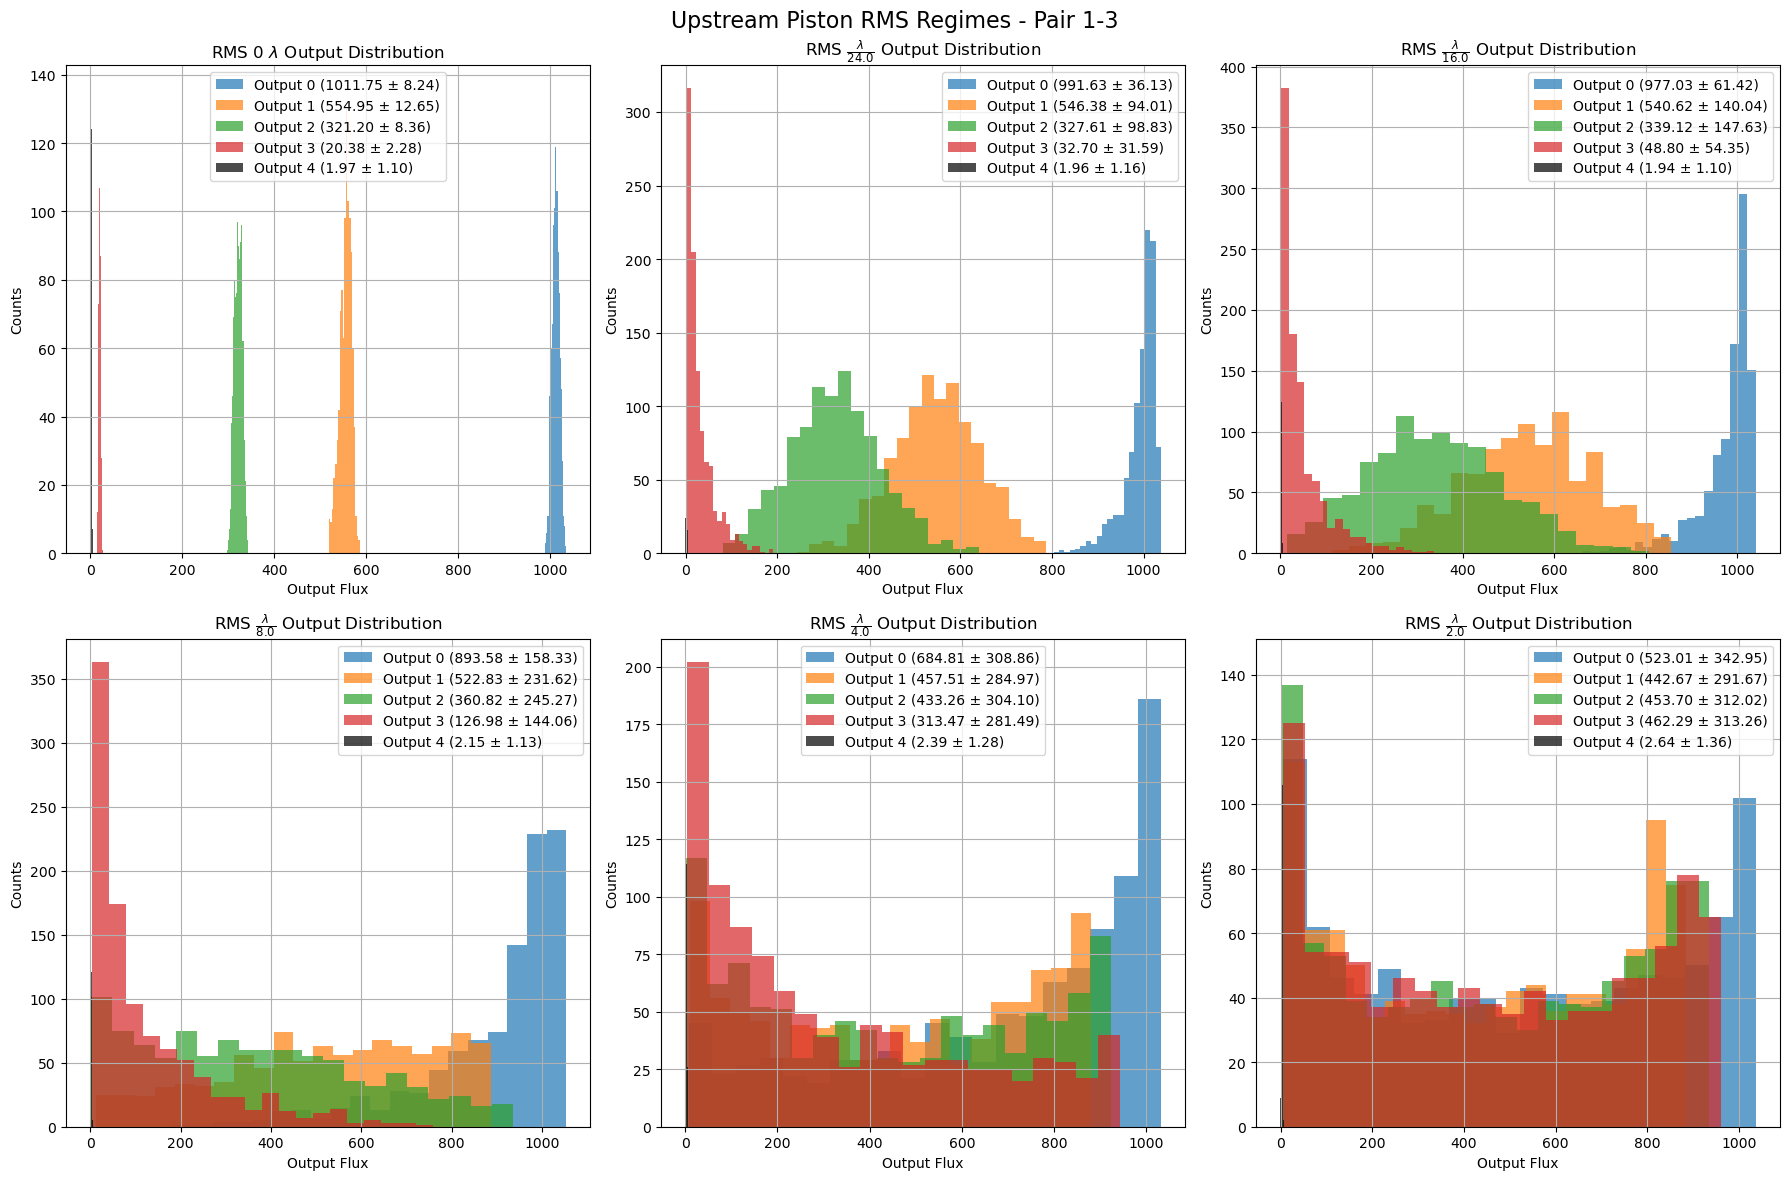

In [ ]:
pair = (1, 3)
rms_values = [0, lam/24., lam/16., lam/8., lam/4., lam/2.][:] # OPD RMS [nm], no change, lam/4, lam/2 (swap), lam, fringe jump.
use_topa = False
use_dm = True
res_rms = rms_scan(1000, rms_values[:], lam, pair, use_topa, True, use_dm)

if use_dm:
    text1 = '_with_dm'
else:
    text1 = ''

if use_topa:
    text2 = '_with_topa'
else:
    text2 = ''

filename = 'fig_rms_pair_%s-%s%s%s.png'%(pair[0], pair[1], text1, text2)
try:
    res_rms['figure'].savefig(path / filename)
except:
    pass

filename = 'res_rms_pair_%s-%s%s%s.pkl'%(pair[0], pair[1], text1, text2)
with open(path / filename, 'wb') as f:
    pickle.dump(res_rms, f)

## Same with TOPA correction

DM stabilisation time (s): 0.002
TOPA stabilization time (s): 0.01
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1, 3] (segments [137, 135])
Ref positions: -1150.0
Scanning RMS=0.0000 nm --- 0 lambda


100%|██████████| 1000/1000 [05:00<00:00,  3.33it/s]


Scanning RMS=64.5833 nm --- lambda/24.0000...


100%|██████████| 1000/1000 [05:00<00:00,  3.33it/s]


Scanning RMS=96.8750 nm --- lambda/16.0000...


...

Scanning RMS=387.5000 nm --- lambda/4.0000...


100%|██████████| 1000/1000 [05:00<00:00,  3.33it/s]


Scanning RMS=775.0000 nm --- lambda/2.0000...


100%|██████████| 1000/1000 [05:00<00:00,  3.33it/s]


Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


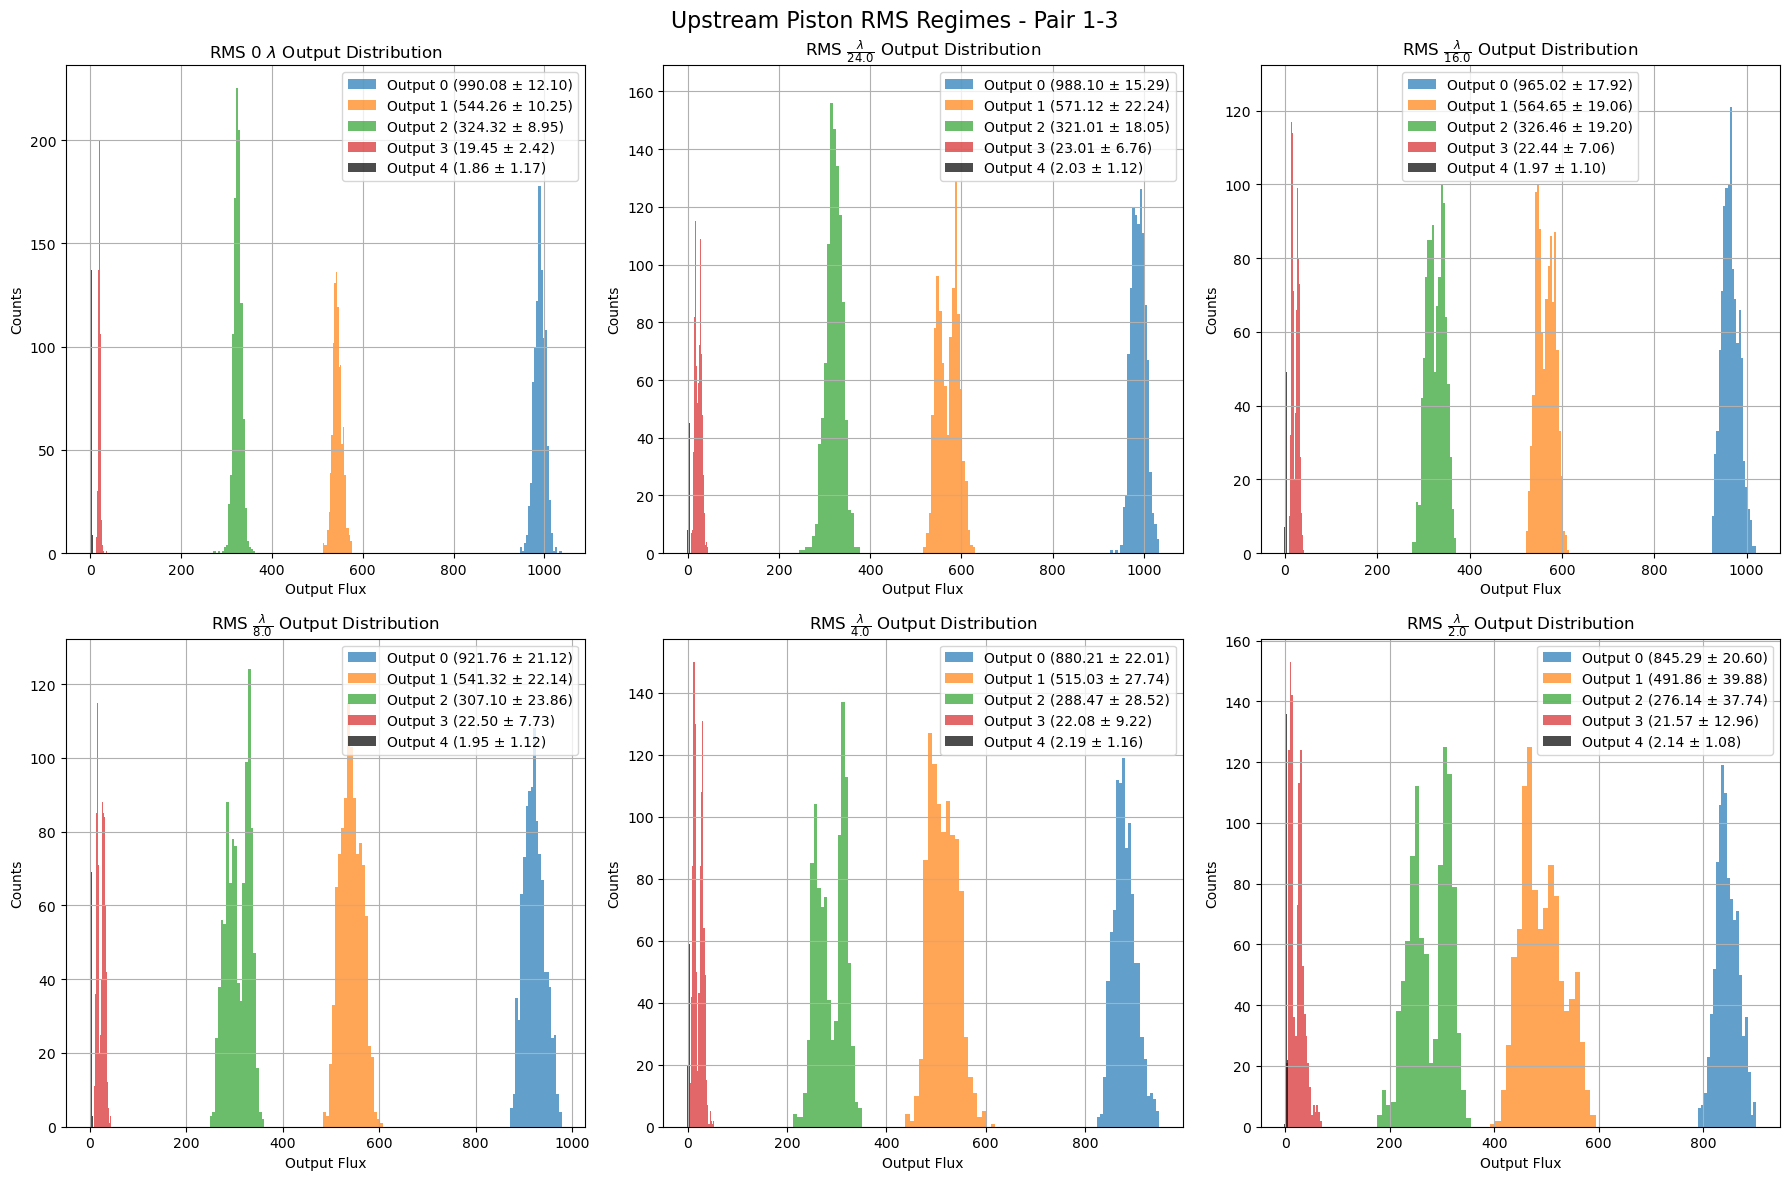

In [ ]:
print('DM stabilisation time (s):', phobos.Config().get('dm.stabilization_time'))
print('TOPA stabilization time (s):', phobos.Config().get('photonic_chip.stabilization_time'))
use_topa = True
use_dm = True

if use_dm:
    text1 = '_with_dm'
else:
    text1 = ''

if use_topa:
    text2 = '_with_topa'
else:
    text2 = ''

res_rms_corrected = rms_scan(1000, rms_values[:], lam, pair, use_topa, True, use_dm)
filename = 'fig_rms_corrected_pair_%s-%s%s%s.png'%(pair[0], pair[1], text1, text2)
res_rms_corrected['figure'].savefig(path / filename)

filename = 'res_rms_corrected_pair_%s-%s%s%s.pkl'%(pair[0], pair[1], text1, text2)
with open(path / filename, 'wb') as f:
    pickle.dump(res_rms_corrected, f)

## With phase shifter alone

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1, 3] (segments [137, 135])
Ref positions: -1150.0
Scanning RMS=0.0000 nm --- 0 lambda


100%|██████████| 1000/1000 [04:58<00:00,  3.35it/s]


Scanning RMS=64.5833 nm --- lambda/24.0000...


100%|██████████| 1000/1000 [04:58<00:00,  3.36it/s]


Scanning RMS=96.8750 nm --- lambda/16.0000...


...

Scanning RMS=387.5000 nm --- lambda/4.0000...


100%|██████████| 1000/1000 [04:58<00:00,  3.35it/s]


Scanning RMS=775.0000 nm --- lambda/2.0000...


100%|██████████| 1000/1000 [04:58<00:00,  3.35it/s]


Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


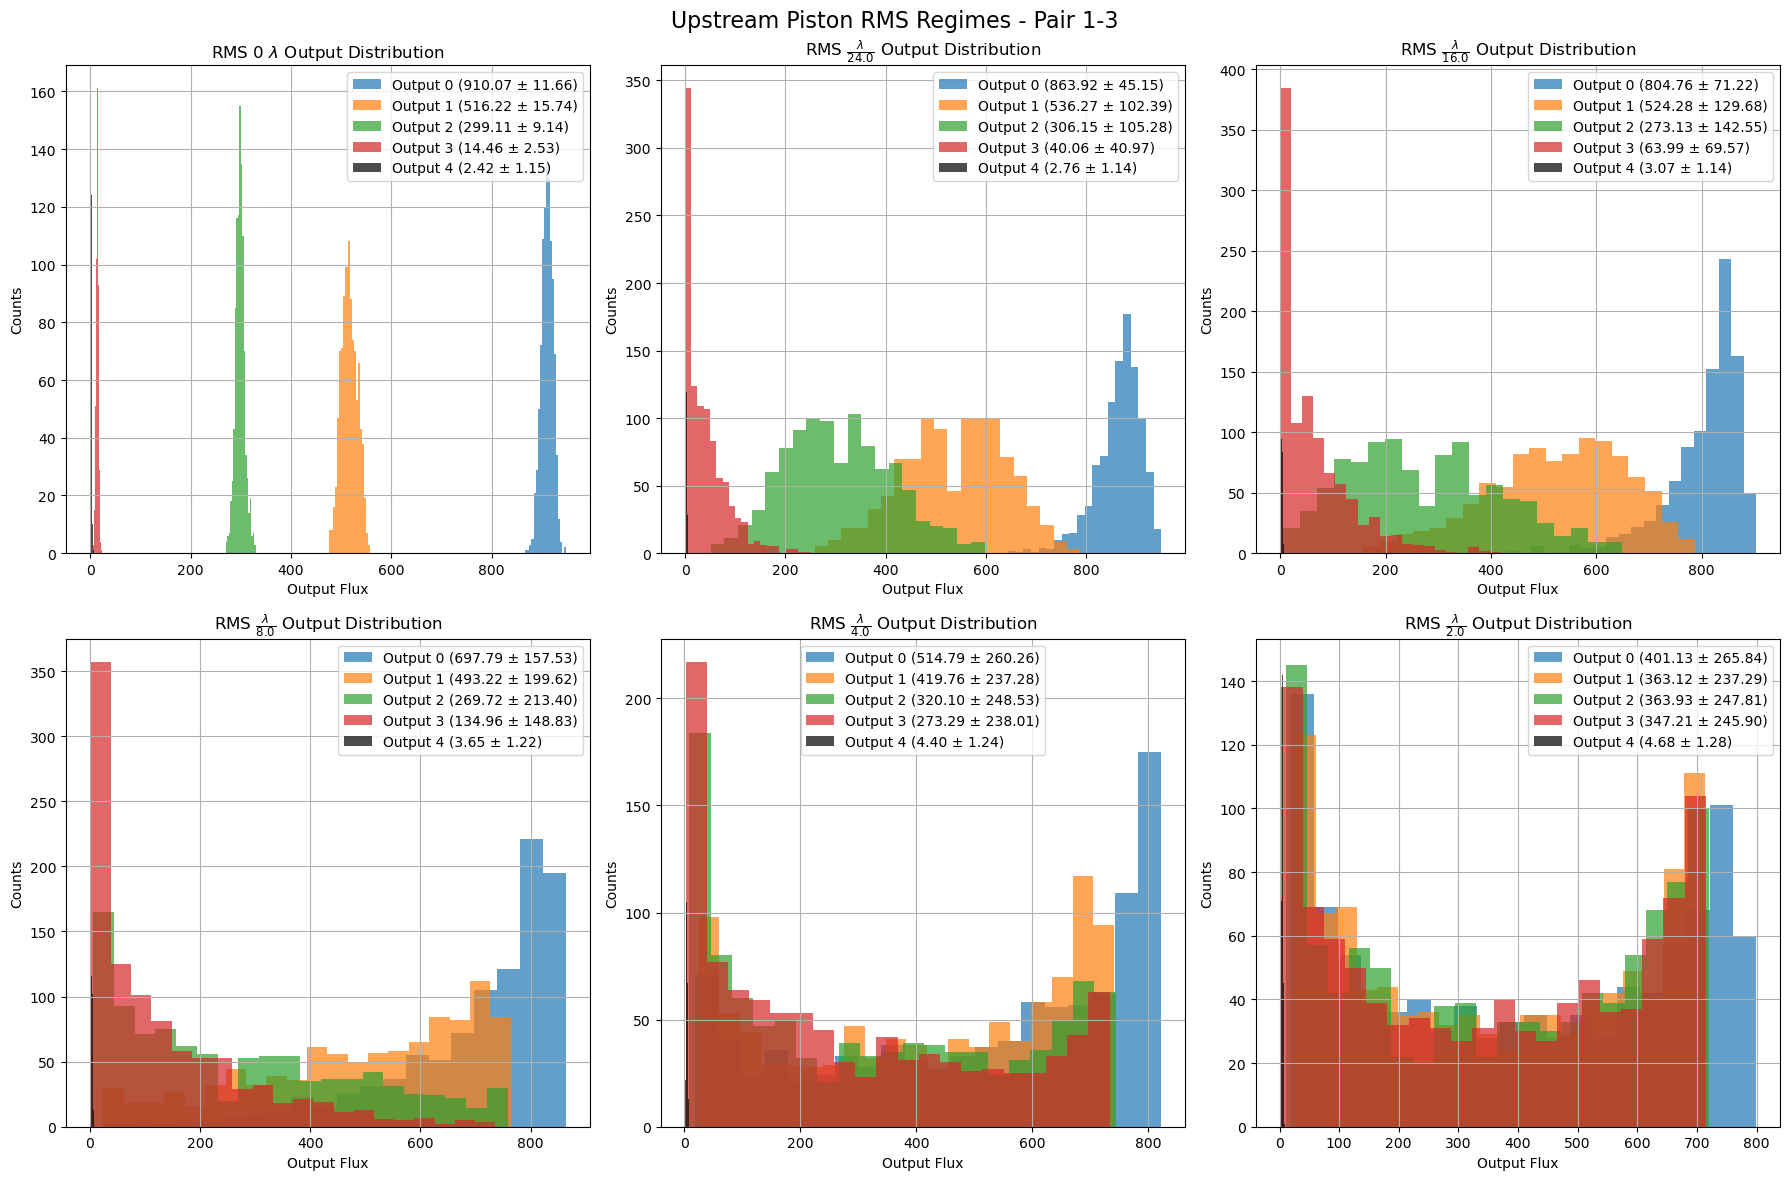

In [ ]:
use_topa = True
use_dm = False

if use_dm:
    text1 = '_with_dm'
else:
    text1 = ''

if use_topa:
    text2 = '_with_topa'
else:
    text2 = ''

res_rms_corrected = rms_scan(1000, rms_values[:], lam, pair, use_topa, True, use_dm)
filename = 'fig_rms_corrected_pair_%s-%s%s%s.png'%(pair[0], pair[1], text1, text2)
res_rms_corrected['figure'].savefig(path / filename)

filename = 'res_rms_corrected_pair_%s-%s%s%s.pkl'%(pair[0], pair[1], text1, text2)
with open(path / filename, 'wb') as f:
    pickle.dump(res_rms_corrected, f)

# Phase shiter crosstalks

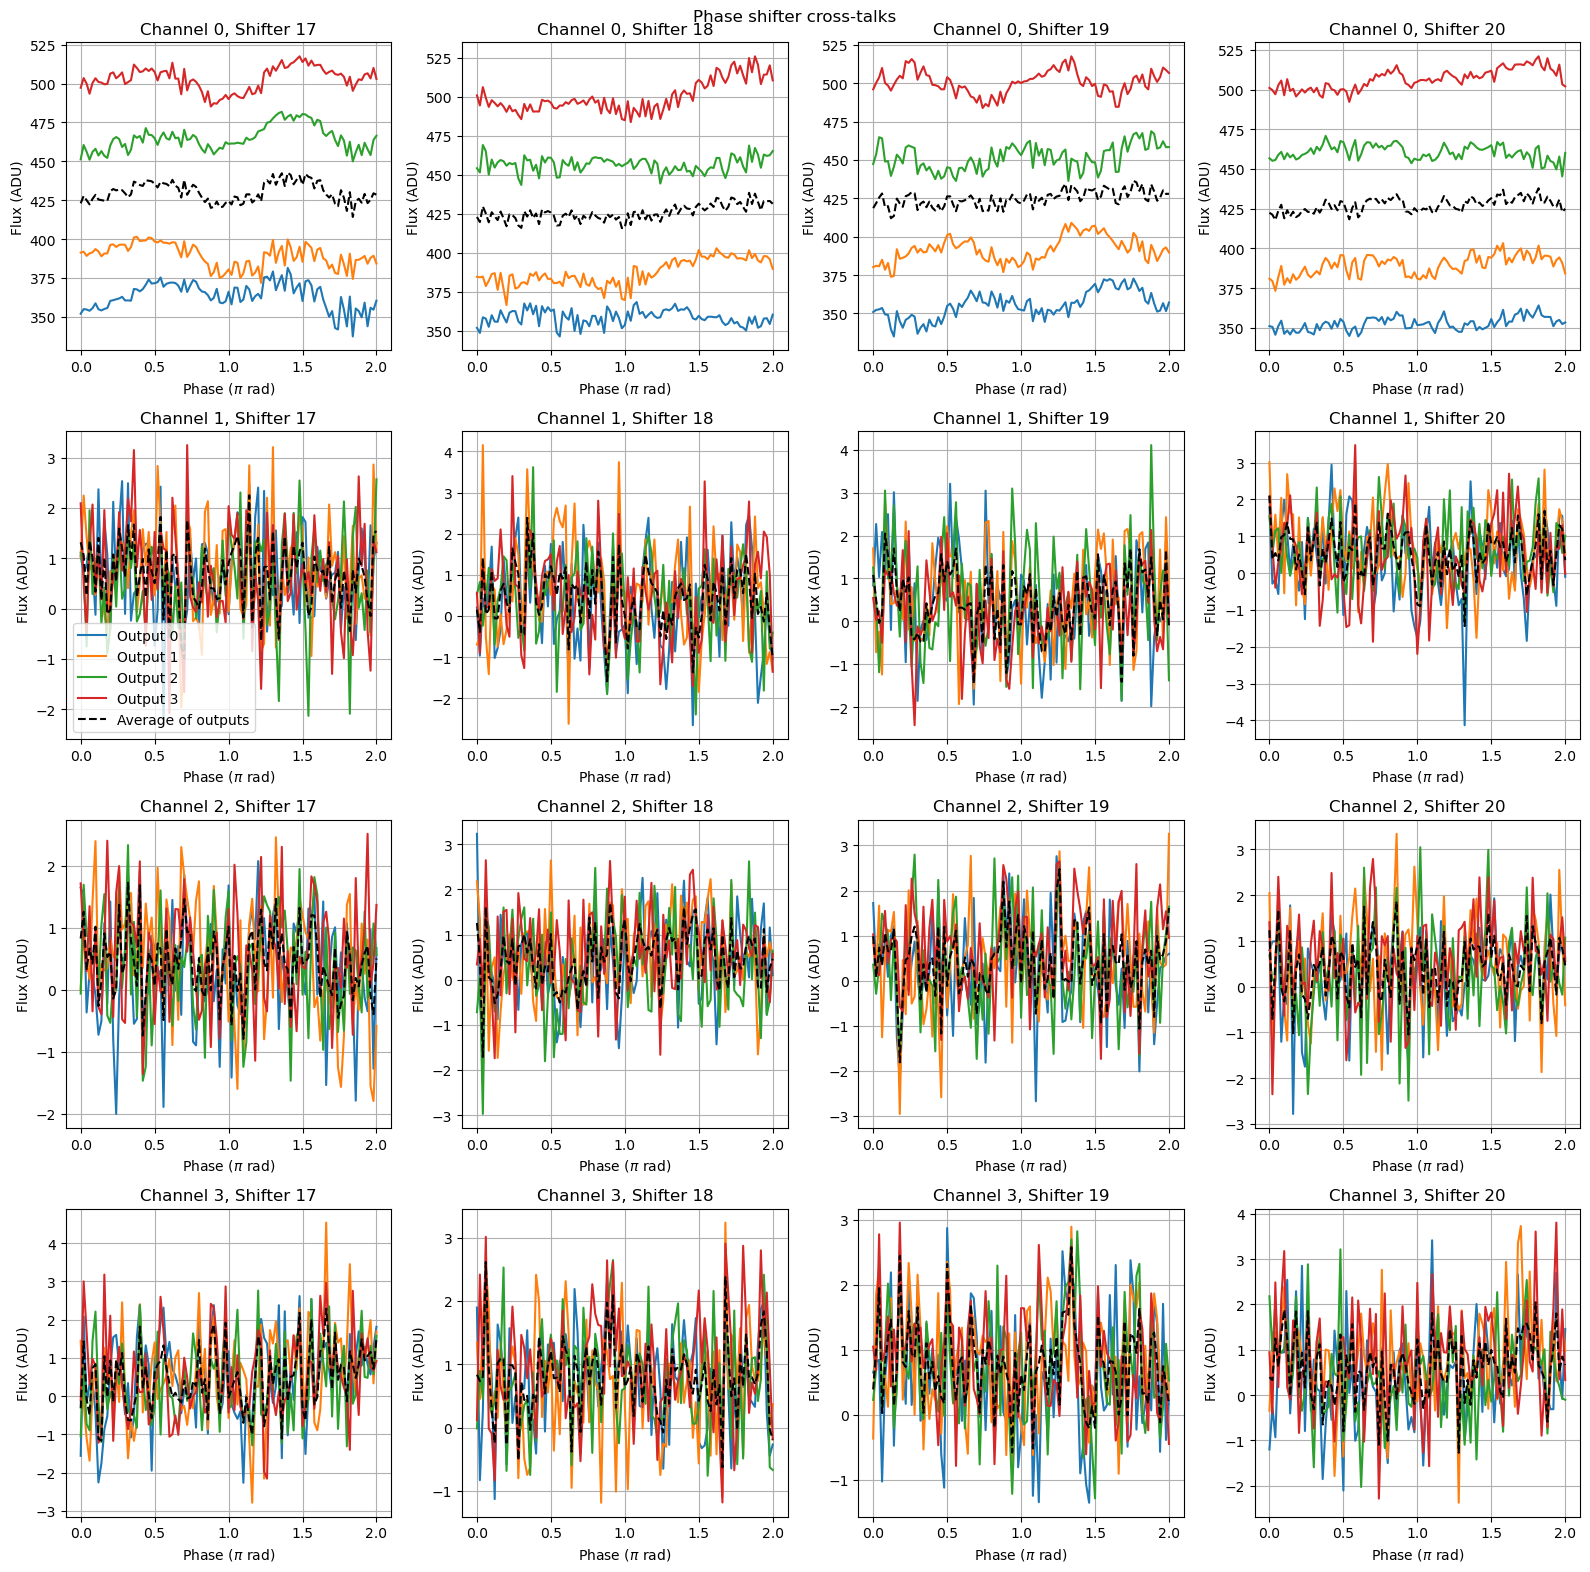

In [ ]:
channels = [0, 1, 2, 3]
phase_ramp = np.linspace(0, 2*np.pi, 101)
n_outputs = 4
beam = 0
seg = inj_seg[beam]
chip.turn_off()

data = []
for ch in channels:
    inj.off()
    inj.set_balanced(ch)
    flx_shifter = []
    for shifter in chip.shifters:
        print('Scanning shifter:', shifter.channel)
        flux = []
        for phase in tqdm(phase_ramp):
            shifter.set_phase(phase)
            flx = cam.get_outputs(flux_mode='mean', stack=5)[:n_outputs]
            flux.append(flx)
        flx_shifter.append(flux)
        shifter.turn_off()
    data.append(flx_shifter)

data = np.array(data) # shape (n_channels, n_shifters, n_phases, n_outputs)
print(data.shape)
np.save(path / f'phase_shifter_seg{seg}_crosstalks', data)

fig, axs = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('Phase shifter cross-talks')
for ch in channels:
    for shifter_idx, shifter in enumerate(chip.shifters):
        axs[ch, shifter_idx].plot(phase_ramp/np.pi, data[ch, shifter_idx])
        axs[ch, shifter_idx].plot(phase_ramp/np.pi, data[ch, shifter_idx].mean(-1), '--', c='k')
        axs[ch, shifter_idx].set_title(f'Channel {ch}, Shifter {shifter.channel}')
        axs[ch, shifter_idx].set_xlabel(r'Phase ($\pi$ rad)')
        axs[ch, shifter_idx].set_ylabel('Flux (ADU)')
        axs[ch, shifter_idx].grid(True)
        if ch == 1 and shifter_idx == 0:
            axs[ch, shifter_idx].legend([f'Output {i}' for i in range(n_outputs)]+['Average of outputs'], loc='best')
fig.tight_layout()
fig.savefig(path / f'phase_shifter_seg{seg}_crosstalks.png', dpi=150)

        

# Environmental drift

## Select pair of beams

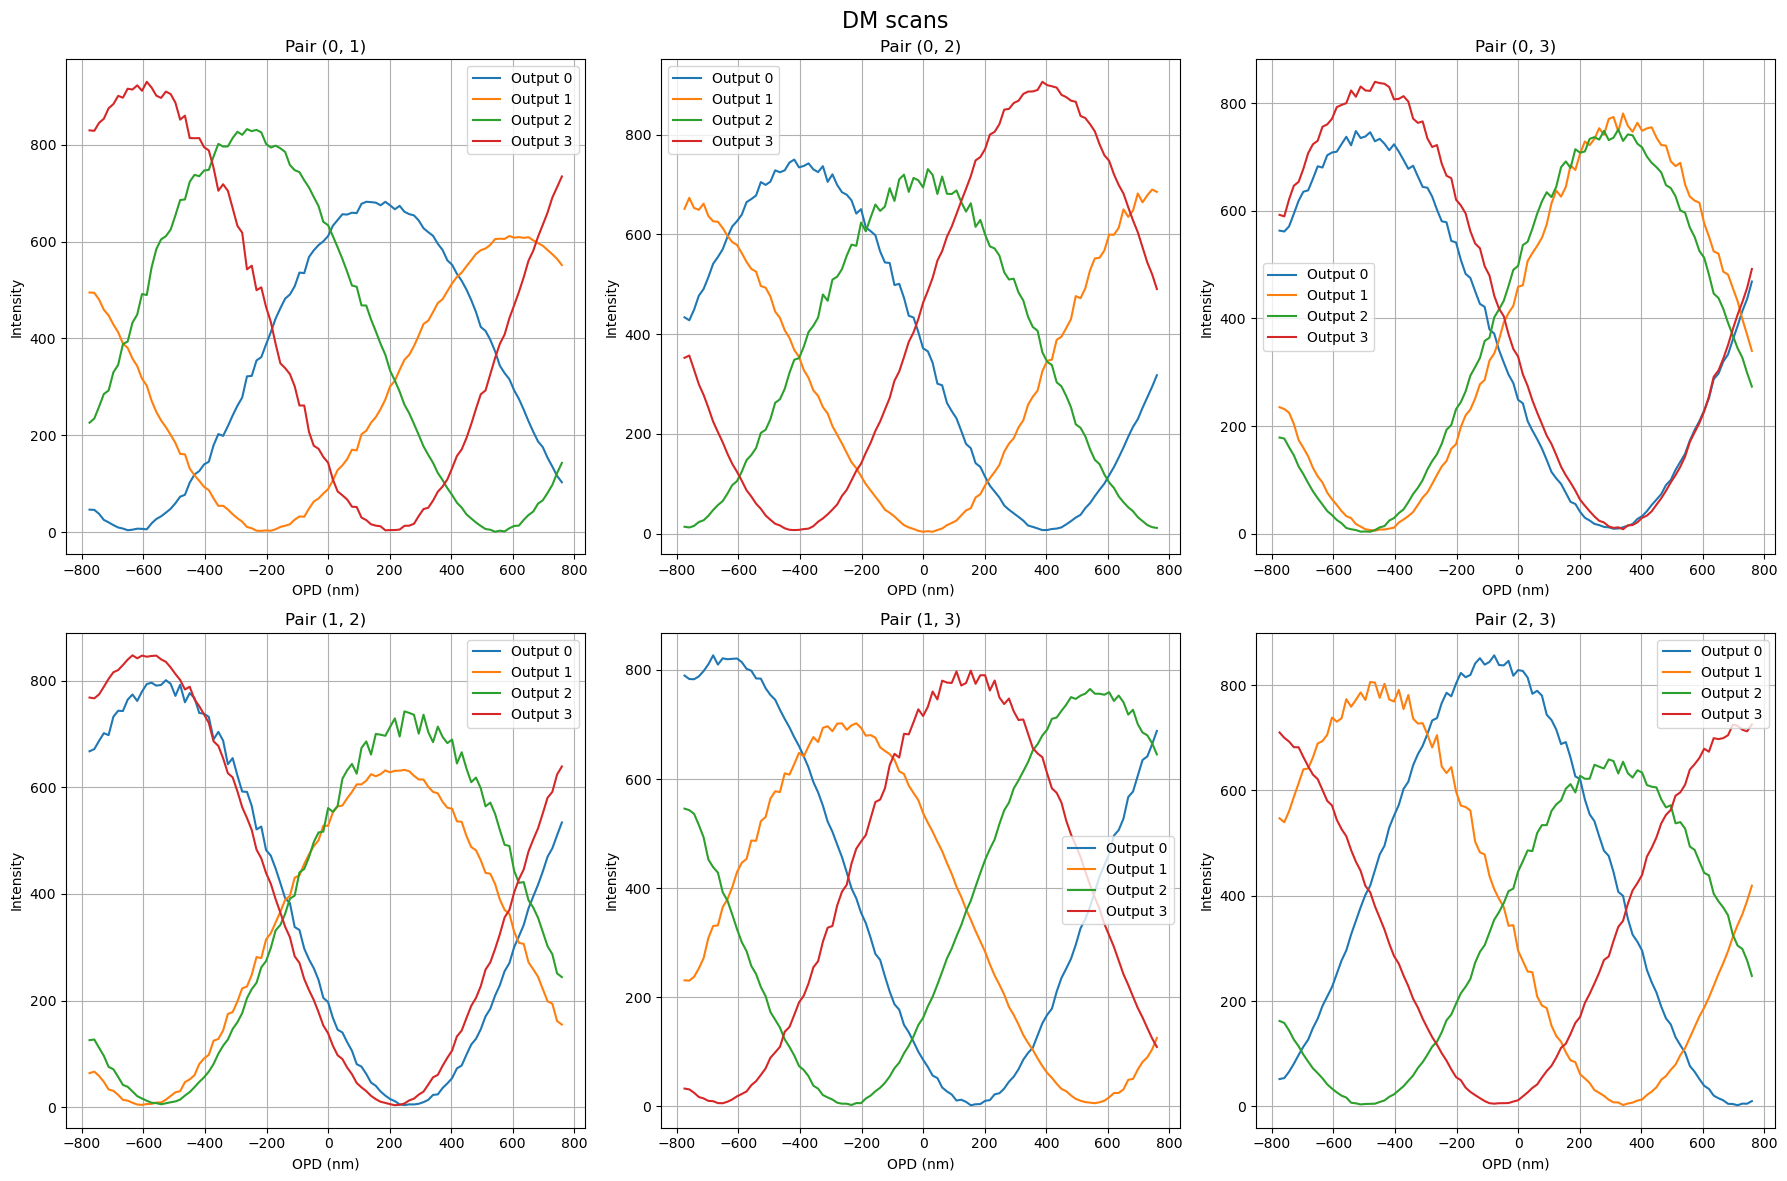

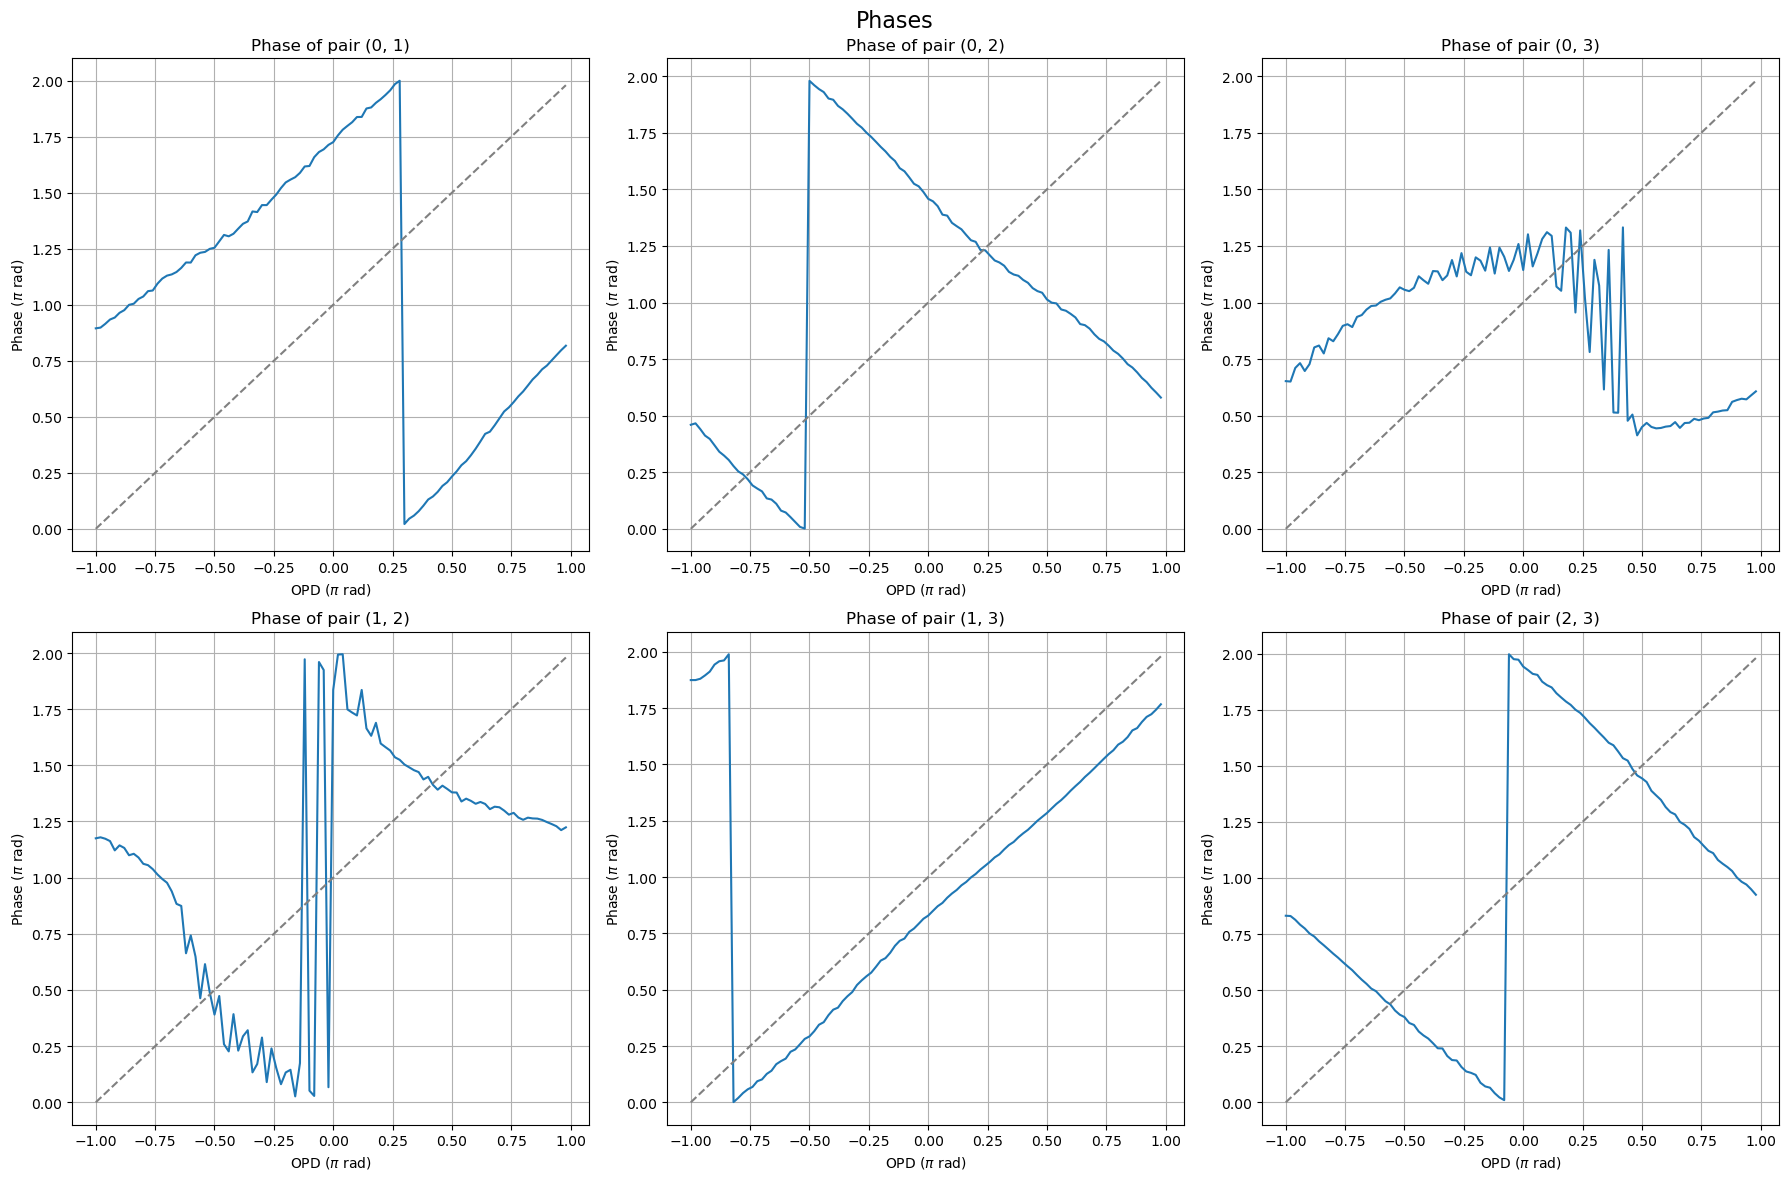

In [16]:
def plot_pairs(data, pairs, title):
    fig, axs = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(title, fontsize=16)
    axs = axs.flatten()
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

    for i, pair in enumerate(pairs):
        ax = axs[i]
        x = data[pair][:,0]
        y = data[pair][:,1:]
        y_revert = data[pair[::-1]][:,1:]
        for j in range(y.shape[1]):
            ax.plot(x, y[:,j], label=f'Output {j}', color=colors[j])
            # ax.plot(x, y_revert[:,j], '--', color=colors[j])
        ax.set_title(f'Pair {pair}')
        ax.set_xlabel('OPD (nm)')
        ax.set_ylabel('Intensity')
        ax.legend()
        ax.grid()
    fig.tight_layout()

def calculate_phases(data, pairs, reframe_phase=True):
    phases = {}
    for pair in pairs:
        d = data[pair]
        x = d[:,0]
        phase = np.arctan2((d[:,2] - d[:,3]), d[:,1] - d[:,4])
        if reframe_phase:
            phase[phase<=0] += 2 * np.pi
        phases[pair] = (x, phase)
    return phases

def plot_phases(phases, title, reframe_phase):
    fig, axs = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(title, fontsize=16)
    axs = axs.flatten()
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

    for i, pair in enumerate(pairs):
        x = phases[pair][0] * 2 * np.pi / 1550
        d = phases[pair][1]

        if reframe_phase:
            x2 = x.copy()
            x2 += np.pi
        ax = axs[i]
        ax.plot(x/np.pi, d / np.pi)
        ax.plot(x/np.pi, x2 / np.pi, '--', color='gray')
        ax.set_title(f'Phase of pair {pair}')
        ax.set_xlabel(r'OPD ($\pi$ rad)')
        ax.set_ylabel(r'Phase ($\pi$ rad)')
        ax.grid()
    fig.tight_layout()
    
filename = 'pair_dm_scan_data_start-1538_nb_lam1.0.pkl'

with open(path / filename, 'rb') as f:
    data = pickle.load(f)

plot_pairs(data, pairs, 'DM scans')
phases = calculate_phases(data, pairs, True)
plot_phases(phases, 'Phases', True)

## Monitor environmental drift

In [17]:
import serial
import serial.tools.list_ports as list_ports

def open_port():
    ports = list(list_ports.comports())

    dev_ii = -1
    if len(ports) == 0:
        print("Arduino board not detected")
        print("Connect Arduino board before starting the program")
        sys.exit()
    else:
        for ii, port in enumerate(ports):
            print(port)
            if "Arduino" in port.description:
                print("Found Arduino")
                dev_ii = ii
                break
        ser = serial.Serial(ports[dev_ii].device, 9600, timeout=1)
        time.sleep(1.0)
        return ser

def read_temp(ser):
    ser.flush()
    try:
        myread = ser.readline().decode('ascii').strip('\r\n')
    except:
        myread = -1

    return myread


In [18]:
temp_probe = open_port()
print('temperature', read_temp(temp_probe))
temp_probe.close()

/dev/ttyS0 - ttyS0
/dev/ttyS1 - ttyS1
/dev/ttyUSBthorlabs - n/a
/dev/ttyUSBzaber - n/a
/dev/ttyUSBnewport - n/a
/dev/ttyUSB2 - CONEX-AGP - CONEX-AGP
/dev/ttyUSB1 - FW102CNEB - FW102CNEB
/dev/ttyUSB0 - FT232R USB UART - FT232R USB UART
/dev/ttyACM0 - Arduino Uno
Found Arduino
temperature 597


In [ ]:
pair = (1, 3)
inj.off()
inj.set_balanced(np.array(pair)) 
chip.turn_off()
temp_probe = open_port()

time_sampling = 0.25 # in min
time_acq = 2. # in h

time_sampling *= 60.
time_acq *= 3600.

nb_points = int(time_acq // time_sampling)

datacube = []
for it in tqdm(range(nb_points)):
    tstamp = time.time()
    fluxes = cam.get_outputs(flux_mode='mean')
    temperature = float(read_temp(temp_probe))
    datacube.append([tstamp, temperature, *fluxes])
    time.sleep(time_sampling)

datacube = np.array(datacube)
filename = 'env_drift_pair%s-%s.npy'%(pair[0], pair[1])
np.save(path / filename, datacube)
print('✅ Data saved in', path / filename)
# Close the serial port
temp_probe.close()


Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1, 3] (segments [137, 135])
/dev/ttyS0 - ttyS0
/dev/ttyS1 - ttyS1
/dev/ttyUSBthorlabs - n/a
/dev/ttyUSBzaber - n/a
/dev/ttyUSBnewport - n/a
/dev/ttyUSB2 - CONEX-AGP - CONEX-AGP
/dev/ttyUSB1 - FW102CNEB - FW102CNEB
/dev/ttyUSB0 - FT232R USB UART - FT232R USB UART
/dev/ttyACM0 - Arduino Uno
Found Arduino


100%|██████████| 480/480 [2:00:03<00:00, 15.01s/it]  


TypeError: unsupported operand type(s) for %: 'PosixPath' and 'tuple'

# The end

In [25]:
print('Path is', path)

inj.zero()

Path is /mnt/disk1/archive/2026-04-17_fdfc996/2_env_drift_lam1550
Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


In [26]:
phobos.XPOW().turn_off()

# Analysis

In [ ]:
def open_pickl(filename):
    with open(filename, 'rb') as f:
        loaded_data = pickle.load(f)
    return loaded_data


Text(0, 0.5, 'Flux (counts)')

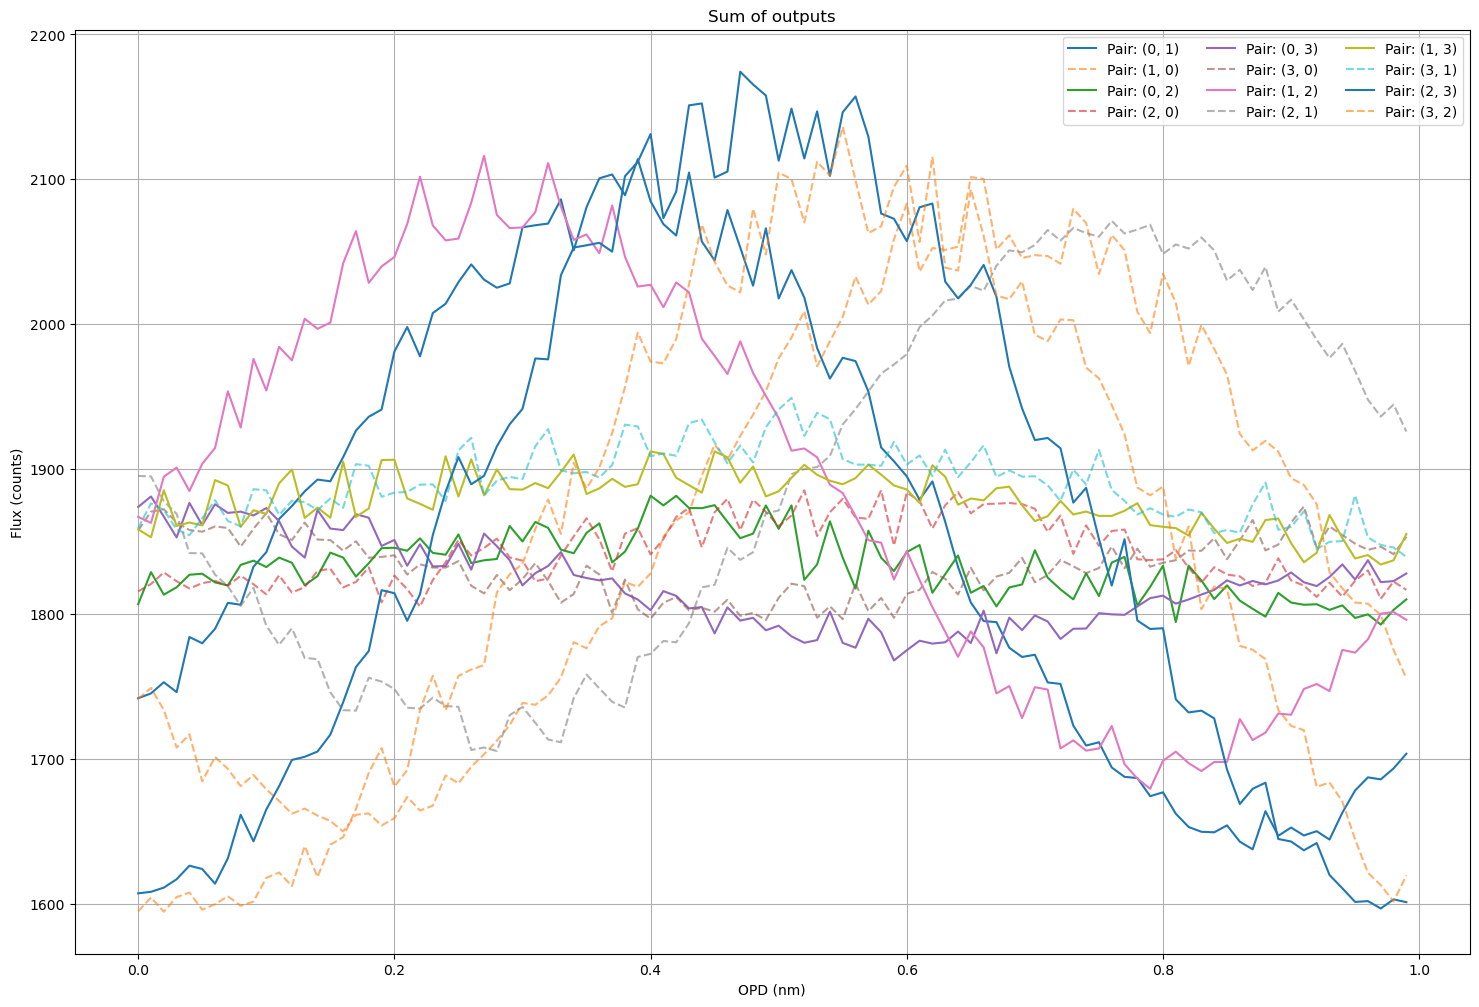

In [ ]:
# Pair scan
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
path = '/mnt/disk1/archive/2026-04-02_065e163/1_topa_scans/'
filename = path + 'pair_scan_data_start-1150_nb_lam1.0.pkl'
loaded_data = open_pickl(filename)

plt.figure(figsize=(18,12))
plt.title('Sum of outputs')
for p in pairs:
    value = loaded_data[p]
    plt.plot(value[:,0] / lam, value[:,1:].sum(axis=1), label=f"Pair: {p}")
    p2 = p[::-1]
    value2 = loaded_data[p2]
    plt.plot(value2[:,0] / lam, value2[:,1:].sum(axis=1), '--', alpha=0.6, label=f"Pair: {p2}")
plt.grid()
plt.legend(ncol=3)
plt.xlabel('OPD (nm)')
plt.ylabel('Flux (counts)')

0.3


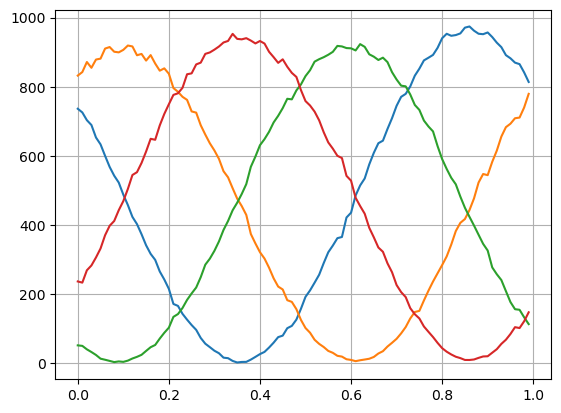

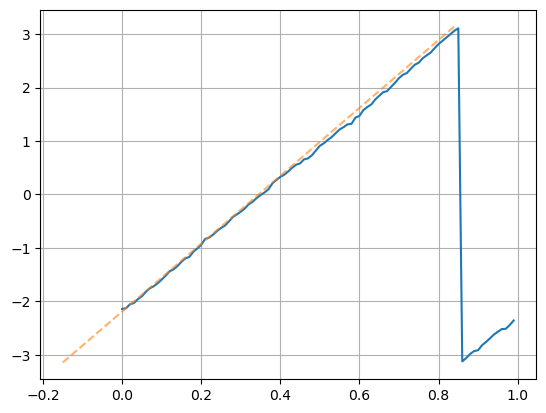

In [ ]:
p = (1, 3)
value = loaded_data[p]

plt.figure()
plt.plot(value[:,0] / lam, value[:, 1:])
plt.grid()

fringes = value[:, 1:]
estimator = np.arctan2(-(fringes[:,1] - fringes[:,2]), -(fringes[:,0] - fringes[:,3]))

phase = np.linspace(-np.pi, np.pi, value[:,0].size)

plt.figure()
plt.plot(value[:,0] / lam, estimator)
plt.plot(value[:,0] / lam - 0.15, phase, '--', alpha=0.6)
plt.grid()

print(2*0.15)